# 可转债多因子研究报告

这份研究底稿使用 `data/cb_data.pq`，从数据检查、因子检验一路做到组合回测。

## 研究背景与任务

### 研究目标

这份底稿按数据检查、单因子测试、多因子打分、组合回测和稳健性观察的顺序展开。想回答的问题很直接：在加入流动性和手续费约束以后，这些常见可转债因子还能不能选出相对更好的标的。

### 统一口径说明

- 所有因子先统一转换为 **分数越高越好**。
- 单因子分组中，`G1` 为低分组，`G5` 为高分组，因此 `long_short = G5 - G1`。
- 正式收益路径采用调仓后日收益连续累积。
- 信号假设为 `t` 日收盘后可观测，并在收盘完成调仓，收益从 `t+1` 开始体现。
- 基准为研究样本等权组合，不计手续费。

### 核心结论

在这批样本里，`dblow` 的分组更顺，`bond_prem` 的统计证据更强，`alpha_pct_chg_5` 提供估值因子之外的短期联动/反转维度。正式成本 `fee_rate=0.002` 下，缓冲排名加权 BW 策略年化收益约 `36.86%`，夏普约 `1.7583`，最大回撤约 `-18.25%`，超额累计收益约 `348.29%`，信息比率约 `1.4356`。


In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

mpl.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'SimSun']
mpl.rcParams['axes.unicode_minus'] = False

DATA_PATH = '../data/cb_data.pq'

OFFICIAL_FEE_RATE = 0.002
OFFICIAL_REBALANCE_FREQ = 'BW'
FEE_SENSITIVITY_LIST = [0.0, 0.001, 0.002, 0.003]

df = pd.read_parquet(DATA_PATH).reset_index()

date_cols = ['trade_date', 'list_date', 'conv_start_date', 'conv_end_date']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

df = df.sort_values(['trade_date', 'code']).reset_index(drop=True)

print('原始数据形状:', df.shape)
print('交易日期范围:', df['trade_date'].min(), '->', df['trade_date'].max())
print('code + trade_date 是否唯一:', not df.duplicated(['code', 'trade_date']).any())

原始数据形状: (559940, 80)
交易日期范围: 2018-01-02 00:00:00 -> 2024-12-26 00:00:00
code + trade_date 是否唯一: True


In [2]:
def make_panel(data: pd.DataFrame, value_col: str) -> pd.DataFrame:
    """将长表转换为 trade_date x code 的宽表。"""
    return data.pivot(index='trade_date', columns='code', values=value_col).sort_index()


def make_forward_return(price_panel: pd.DataFrame, periods: int = 1) -> pd.DataFrame:
    """基于价格面板计算未来 N 期收益，默认是未来 1 日收益。"""
    return price_panel.pct_change(periods=periods, fill_method=None).shift(-periods)


def make_periodic_forward_return(price_panel: pd.DataFrame, freq: str = 'W') -> pd.DataFrame:
    """扩展函数：按指定周期计算 future return，仅作为补充，不替换主方案。"""
    price_panel = price_panel.sort_index()
    if freq == 'D':
        return make_forward_return(price_panel, periods=1)
    if freq == 'W':
        period_index = price_panel.index.to_period('W')
    elif freq == 'BW':
        week_periods = pd.Series(price_panel.index, index=price_panel.index).dt.to_period('W')
        week_ids = pd.Series(pd.factorize(week_periods)[0], index=price_panel.index)
        period_index = week_ids // 2
    elif freq == 'M':
        period_index = price_panel.index.to_period('M')
    else:
        raise ValueError("freq only supports 'D', 'W', 'BW', or 'M'")
    period_close = price_panel.groupby(period_index).last()
    return period_close.pct_change(fill_method=None).shift(-1)


def winsorize_row(row: pd.Series, q: float = 0.02) -> pd.Series:
    """按行做截面去极值。"""
    valid = row.dropna()
    if valid.empty:
        return row
    lo = valid.quantile(q)
    hi = valid.quantile(1 - q)
    return row.clip(lo, hi)


def zscore_row(row: pd.Series) -> pd.Series:
    """按行做截面标准化。"""
    std = row.std()
    if pd.isna(std) or std == 0:
        return row * np.nan
    return (row - row.mean()) / std


def normalize_cross_section(panel: pd.DataFrame, q: float = 0.02) -> pd.DataFrame:
    """先去极值，再做截面 z-score 标准化。"""
    return panel.apply(winsorize_row, axis=1, q=q).apply(zscore_row, axis=1)


def prepare_research_sample(data: pd.DataFrame) -> pd.DataFrame:
    """稳健构造研究样本，并输出过滤前后统计。"""
    data = data.copy().sort_values(['trade_date', 'code'])
    before_rows = len(data)
    before_days = data['trade_date'].nunique()
    before_daily_mean = data.groupby('trade_date')['code'].nunique().mean()

    mask = pd.Series(True, index=data.index)

    if 'amount' in data.columns:
        mask &= data['amount'].fillna(0).gt(0)
    else:
        print("警告：缺少 amount 字段，跳过成交额过滤。")

    if 'turnover' in data.columns:
        mask &= data['turnover'].fillna(0).gt(0)
    else:
        print("警告：缺少 turnover 字段，跳过换手率过滤。")

    if 'left_conv_start_days' in data.columns:
        mask &= data['left_conv_start_days'].fillna(np.inf).le(0)
    else:
        print("警告：缺少 left_conv_start_days 字段，跳过转股期过滤。")

    if 'left_years' in data.columns:
        mask &= data['left_years'].fillna(-np.inf).gt(0.3)
    else:
        print("警告：缺少 left_years 字段，跳过剩余期限过滤。")

    filtered = data.loc[mask].copy()

    after_rows = len(filtered)
    after_days = filtered['trade_date'].nunique()
    after_daily_mean = filtered.groupby('trade_date')['code'].nunique().mean() if after_rows > 0 else np.nan

    summary = pd.DataFrame({
        'metric': ['rows', 'trade_days', 'avg_daily_universe'],
        'before': [before_rows, before_days, before_daily_mean],
        'after': [after_rows, after_days, after_daily_mean],
    })
    summary['change'] = summary['after'] - summary['before']
    summary['change_pct'] = summary['after'] / summary['before'] - 1
    print('样本过滤汇总:')
    display(summary)
    return filtered


def calc_ic_series(factor_panel: pd.DataFrame, fwd_ret_panel: pd.DataFrame) -> pd.DataFrame:
    """计算日度 IC 和 RankIC 序列。factor_panel 已统一为分数越高越好。"""
    aligned_factor = factor_panel.reindex_like(fwd_ret_panel)
    ic = aligned_factor.corrwith(fwd_ret_panel, axis=1)
    rankic = aligned_factor.rank(axis=1, pct=True).corrwith(
        fwd_ret_panel.rank(axis=1, pct=True), axis=1
    )
    return pd.DataFrame({'IC': ic, 'RankIC': rankic})


def factor_summary(ic_df: pd.DataFrame) -> pd.Series:
    """汇总因子 IC / RankIC 的均值、波动与 IR。"""
    ic_mean = ic_df['IC'].mean()
    ic_std = ic_df['IC'].std()
    rankic_mean = ic_df['RankIC'].mean()
    rankic_std = ic_df['RankIC'].std()
    return pd.Series({
        'IC mean': ic_mean,
        'IC std': ic_std,
        'ICIR': ic_mean / ic_std if ic_std and not pd.isna(ic_std) else np.nan,
        'RankIC mean': rankic_mean,
        'RankIC std': rankic_std,
        'RankICIR': rankic_mean / rankic_std if rankic_std and not pd.isna(rankic_std) else np.nan,
    })


def group_backtest(factor_panel: pd.DataFrame, fwd_ret_panel: pd.DataFrame, n_group: int = 5) -> pd.DataFrame:
    """单因子分组回测。已统一为分数越高越好，因此 long_short = G5 - G1。"""
    def _row_to_group(row: pd.Series) -> pd.Series:
        valid = row.dropna()
        if valid.nunique() < n_group:
            return pd.Series(index=row.index, dtype=float)
        ranks = valid.rank(method='first')
        labels = pd.qcut(ranks, q=n_group, labels=False, duplicates='drop') + 1
        out = pd.Series(index=row.index, dtype=float)
        out.loc[valid.index] = labels.astype(float)
        return out

    group_label = factor_panel.apply(_row_to_group, axis=1)
    group_ret = pd.DataFrame(index=factor_panel.index)
    for g in range(1, n_group + 1):
        mask = group_label.eq(g)
        group_ret[f'G{g}'] = fwd_ret_panel.where(mask).mean(axis=1)

    group_ret['long_short'] = group_ret[f'G{n_group}'] - group_ret['G1']
    return (1 + group_ret.fillna(0)).cumprod()


def build_composite_score(data: pd.DataFrame, factor_spec: dict, q: float = 0.02) -> pd.DataFrame:
    """构建多因子综合分数，最终统一为分数越高越好。"""
    score_list = []
    for col, sign in factor_spec.items():
        panel = make_panel(data, col)
        score = normalize_cross_section(panel, q=q) * sign
        score_list.append(score)
    return sum(score_list) / len(score_list)


def get_rebalance_flag(index: pd.DatetimeIndex, freq: str = 'W') -> pd.Series:
    """生成 D/W/BW/M 调仓标记。BW 为每两周首个可交易日调仓。"""
    s = pd.Series(index, index=index)
    if freq == 'D':
        return pd.Series(True, index=index)
    if freq == 'W':
        return s.dt.to_period('W').ne(s.shift(1).dt.to_period('W'))
    if freq == 'BW':
        week_periods = s.dt.to_period('W')
        week_ids = pd.Series(pd.factorize(week_periods)[0], index=index)
        is_new_week = week_periods.ne(week_periods.shift(1))
        return week_ids.mod(2).eq(0) & is_new_week
    if freq == 'M':
        return s.dt.to_period('M').ne(s.shift(1).dt.to_period('M'))
    raise ValueError("freq only supports 'D', 'W', 'BW', or 'M'")


def topn_equal_weight_backtest(score_panel: pd.DataFrame, fwd_ret_panel: pd.DataFrame, top_n: int = 20, rebalance_freq: str = 'W', fee_rate: float = OFFICIAL_FEE_RATE) -> pd.DataFrame:
    """TopN 等权组合回测。主口径为周/月调仓 + 日收益累积净值。"""
    rank_panel = score_panel.rank(axis=1, ascending=False, method='first')
    target_weight = rank_panel.le(top_n).astype(float)
    target_weight = target_weight.div(target_weight.sum(axis=1), axis=0)

    rebalance_flag = get_rebalance_flag(score_panel.index, freq=rebalance_freq)
    weight = target_weight.where(rebalance_flag, np.nan).ffill().fillna(0)

    gross_ret = (weight * fwd_ret_panel).sum(axis=1)
    turnover = weight.fillna(0).diff().abs().sum(axis=1)
    turnover.iloc[0] = weight.iloc[0].abs().sum()

    net_ret = gross_ret - fee_rate * turnover
    nav = (1 + net_ret.fillna(0)).cumprod()
    return pd.DataFrame({'gross_ret': gross_ret, 'turnover': turnover, 'net_ret': net_ret, 'nav': nav})


def topn_buffer_equal_weight_backtest(
    score_panel: pd.DataFrame,
    fwd_ret_panel: pd.DataFrame,
    buy_n: int = 10,
    sell_n: int = 15,
    rebalance_freq: str = 'W',
    fee_rate: float = OFFICIAL_FEE_RATE,
) -> pd.DataFrame:
    """带换手缓冲区的等权回测。"""
    rank_panel = score_panel.rank(axis=1, ascending=False, method='first')
    rebalance_flag = get_rebalance_flag(score_panel.index, freq=rebalance_freq)

    weight = pd.DataFrame(0.0, index=score_panel.index, columns=score_panel.columns)
    current_holdings = set()
    prev_weight = pd.Series(0.0, index=score_panel.columns)

    for dt in score_panel.index:
        if rebalance_flag.loc[dt]:
            ranks = rank_panel.loc[dt].dropna().sort_values()
            rank_map = ranks.to_dict()
            keep = {code for code in current_holdings if code in rank_map and rank_map[code] <= sell_n}
            final_codes = [code for code in ranks.index if (code in keep) or (rank_map[code] <= buy_n)]

            new_weight = pd.Series(0.0, index=score_panel.columns)
            m = len(final_codes)
            if m > 0:
                new_weight.loc[final_codes] = 1.0 / m

            current_holdings = set(final_codes)
            prev_weight = new_weight
            weight.loc[dt] = new_weight
        else:
            weight.loc[dt] = prev_weight

    gross_ret = (weight * fwd_ret_panel).sum(axis=1)
    turnover = weight.fillna(0).diff().abs().sum(axis=1)
    turnover.iloc[0] = weight.iloc[0].abs().sum()

    net_ret = gross_ret - fee_rate * turnover
    nav = (1 + net_ret.fillna(0)).cumprod()
    return pd.DataFrame({'gross_ret': gross_ret, 'turnover': turnover, 'net_ret': net_ret, 'nav': nav})


def topn_rank_weight_backtest(
    score_panel: pd.DataFrame,
    fwd_ret_panel: pd.DataFrame,
    top_n: int = 10,
    rebalance_freq: str = 'W',
    fee_rate: float = OFFICIAL_FEE_RATE,
) -> pd.DataFrame:
    """不加缓冲区的线性 rank-weight 回测。"""
    rank_panel = score_panel.rank(axis=1, ascending=False, method='first')

    def _rank_weight_row(row: pd.Series) -> pd.Series:
        selected = row[row <= top_n].sort_values()
        out = pd.Series(0.0, index=row.index)
        m = len(selected)
        if m > 0:
            raw_weight = np.arange(m, 0, -1, dtype=float)
            raw_weight = raw_weight / raw_weight.sum()
            out.loc[selected.index] = raw_weight
        return out

    target_weight = rank_panel.apply(_rank_weight_row, axis=1)
    rebalance_flag = get_rebalance_flag(score_panel.index, freq=rebalance_freq)
    weight = target_weight.where(rebalance_flag, np.nan).ffill().fillna(0)

    gross_ret = (weight * fwd_ret_panel).sum(axis=1)
    turnover = weight.fillna(0).diff().abs().sum(axis=1)
    turnover.iloc[0] = weight.iloc[0].abs().sum()

    net_ret = gross_ret - fee_rate * turnover
    nav = (1 + net_ret.fillna(0)).cumprod()
    return pd.DataFrame({'gross_ret': gross_ret, 'turnover': turnover, 'net_ret': net_ret, 'nav': nav})




def topn_buffer_rank_weight_backtest(
    score_panel: pd.DataFrame,
    fwd_ret_panel: pd.DataFrame,
    buy_n: int = 10,
    sell_n: int = 15,
    rebalance_freq: str = 'W',
    fee_rate: float = OFFICIAL_FEE_RATE,
) -> pd.DataFrame:
    """Top10/Top15 buffer holdings plus rank weighting within current holdings."""
    rank_panel = score_panel.rank(axis=1, ascending=False, method='first')
    rebalance_flag = get_rebalance_flag(score_panel.index, freq=rebalance_freq)

    weight = pd.DataFrame(0.0, index=score_panel.index, columns=score_panel.columns)
    current_holdings = set()
    prev_weight = pd.Series(0.0, index=score_panel.columns)

    for dt in score_panel.index:
        if rebalance_flag.loc[dt]:
            ranks = rank_panel.loc[dt].dropna().sort_values()
            rank_map = ranks.to_dict()
            keep = {code for code in current_holdings if code in rank_map and rank_map[code] <= sell_n}
            final_codes = [code for code in ranks.index if (code in keep) or (rank_map[code] <= buy_n)]

            new_weight = pd.Series(0.0, index=score_panel.columns)
            if final_codes:
                selected = ranks.loc[final_codes].sort_values()
                m = len(selected)
                raw_weight = np.arange(m, 0, -1, dtype=float)
                raw_weight = raw_weight / raw_weight.sum()
                new_weight.loc[selected.index] = raw_weight

            current_holdings = set(final_codes)
            prev_weight = new_weight
            weight.loc[dt] = new_weight
        else:
            weight.loc[dt] = prev_weight

    gross_ret = (weight * fwd_ret_panel).sum(axis=1)
    turnover = weight.fillna(0).diff().abs().sum(axis=1)
    turnover.iloc[0] = weight.iloc[0].abs().sum()

    net_ret = gross_ret - fee_rate * turnover
    nav = (1 + net_ret.fillna(0)).cumprod()
    return pd.DataFrame({'gross_ret': gross_ret, 'turnover': turnover, 'net_ret': net_ret, 'nav': nav})

def summarize_performance(ret: pd.Series, nav: pd.Series, turnover: pd.Series = None, periods_per_year: int = 244) -> pd.Series:
    """汇总组合绩效指标。"""
    ret = ret.fillna(0)
    nav = nav.ffill().fillna(1.0)

    total_return = nav.iloc[-1] - 1
    annual_return = nav.iloc[-1] ** (periods_per_year / len(nav)) - 1
    annual_vol = ret.std() * np.sqrt(periods_per_year)
    sharpe = annual_return / annual_vol if annual_vol > 0 else np.nan
    drawdown = nav / nav.cummax() - 1
    max_drawdown = drawdown.min()
    calmar = annual_return / abs(max_drawdown) if max_drawdown < 0 else np.nan
    win_rate = (ret > 0).mean()
    avg_turnover = turnover.mean() if turnover is not None else np.nan

    return pd.Series({
        'total_return': total_return,
        'annual_return': annual_return,
        'annual_vol': annual_vol,
        'sharpe': sharpe,
        'max_drawdown': max_drawdown,
        'calmar': annual_return / abs(max_drawdown) if max_drawdown < 0 else np.nan,
        'win_rate': win_rate,
        'avg_turnover': avg_turnover,
    })


def calc_yearly_max_drawdown(nav: pd.Series) -> pd.Series:
    """按自然年计算最大回撤。"""
    nav = nav.ffill().dropna()
    return nav.groupby(nav.index.year).apply(lambda x: (x / x.cummax() - 1).min())


def calc_ir(excess_ret: pd.Series, periods_per_year: int = 244) -> float:
    """计算相对基准的年化信息比率。"""
    ann_excess = excess_ret.mean() * periods_per_year
    ann_excess_vol = excess_ret.std() * np.sqrt(periods_per_year)
    return ann_excess / ann_excess_vol if ann_excess_vol > 0 else np.nan

def calc_yearly_performance(ret: pd.Series, turnover: pd.Series = None) -> pd.DataFrame:
    """按自然年汇总年化收益、夏普、最大回撤和换手。"""
    rows = []
    for year, sub_ret in ret.fillna(0).groupby(ret.index.year):
        sub_nav = (1 + sub_ret).cumprod()
        sub_turnover = turnover.reindex(sub_ret.index) if turnover is not None else None
        s = summarize_performance(sub_ret, sub_nav, sub_turnover)
        s.name = year
        rows.append(s)
    out = pd.DataFrame(rows)
    out.index.name = 'year'
    return out


def top_bottom_quantile_hedge_backtest(
    score_panel: pd.DataFrame,
    fwd_ret_panel: pd.DataFrame,
    quantile: float = 0.20,
) -> pd.DataFrame:
    """每日最高分位减最低分位的等权多空验证，默认 top 20% - bottom 20%。"""
    rank_pct = score_panel.rank(axis=1, pct=True, ascending=True, method='first')
    long_mask = rank_pct.ge(1 - quantile)
    short_mask = rank_pct.le(quantile)
    long_ret = fwd_ret_panel.where(long_mask).mean(axis=1)
    short_ret = fwd_ret_panel.where(short_mask).mean(axis=1)
    hedge_ret = long_ret - short_ret
    hedge_nav = (1 + hedge_ret.fillna(0)).cumprod()
    return pd.DataFrame({
        'long_ret': long_ret,
        'short_ret': short_ret,
        'ret': hedge_ret,
        'nav': hedge_nav,
    })


def topn_buffer_threshold_backtest(
    score_panel: pd.DataFrame,
    fwd_ret_panel: pd.DataFrame,
    buy_n: int = 10,
    sell_n: int = 15,
    rebalance_freq: str = 'W',
    fee_rate: float = OFFICIAL_FEE_RATE,
    trade_threshold: float = 0.02,
) -> pd.DataFrame:
    """附录用：仅当单券权重变化超过阈值时交易，不替代主策略。"""
    rank_panel = score_panel.rank(axis=1, ascending=False, method='first')
    rebalance_flag = get_rebalance_flag(score_panel.index, freq=rebalance_freq)

    weight = pd.DataFrame(0.0, index=score_panel.index, columns=score_panel.columns)
    current_holdings = set()
    prev_weight = pd.Series(0.0, index=score_panel.columns)

    for dt in score_panel.index:
        if rebalance_flag.loc[dt]:
            ranks = rank_panel.loc[dt].dropna().sort_values()
            rank_map = ranks.to_dict()
            keep = {code for code in current_holdings if code in rank_map and rank_map[code] <= sell_n}
            final_codes = [code for code in ranks.index if (code in keep) or (rank_map[code] <= buy_n)]

            target_weight = pd.Series(0.0, index=score_panel.columns)
            m = len(final_codes)
            if m > 0:
                target_weight.loc[final_codes] = 1.0 / m

            trade_mask = (target_weight - prev_weight).abs().gt(trade_threshold)
            new_weight = prev_weight.copy()
            if trade_mask.any():
                new_weight.loc[trade_mask] = target_weight.loc[trade_mask]

            total_weight = new_weight.sum()
            if total_weight > 0:
                new_weight = new_weight / total_weight

            current_holdings = set(new_weight[new_weight > 0].index.tolist())
            prev_weight = new_weight
            weight.loc[dt] = new_weight
        else:
            weight.loc[dt] = prev_weight

    gross_ret = (weight * fwd_ret_panel).sum(axis=1)
    turnover = weight.fillna(0).diff().abs().sum(axis=1)
    turnover.iloc[0] = weight.iloc[0].abs().sum()

    net_ret = gross_ret - fee_rate * turnover
    nav = (1 + net_ret.fillna(0)).cumprod()
    return pd.DataFrame({'gross_ret': gross_ret, 'turnover': turnover, 'net_ret': net_ret, 'nav': nav})


def apply_cross_section_quantile_filter(panel: pd.DataFrame, quantile: float = 0.20, keep: str = 'ge') -> pd.DataFrame:
    """按日截面分位数生成过滤掩码。"""
    def _row_filter(row: pd.Series) -> pd.Series:
        valid = row.dropna()
        out = pd.Series(False, index=row.index)
        if valid.empty:
            return out
        threshold = valid.quantile(quantile)
        if keep == 'ge':
            out.loc[valid.index] = valid.ge(threshold)
        elif keep == 'gt':
            out.loc[valid.index] = valid.gt(threshold)
        else:
            raise ValueError("keep only supports 'ge' or 'gt'")
        return out

    return panel.apply(_row_filter, axis=1)


def make_strategy_snapshot(result: pd.DataFrame, benchmark_ret: pd.Series) -> pd.Series:
    """汇总单个策略版本的核心绩效与超额指标；切片区间内重新累积净值。"""
    ret = result['net_ret'].fillna(0)
    turnover = result['turnover'] if 'turnover' in result else None
    nav = (1 + ret).cumprod()
    perf = summarize_performance(ret, nav, turnover)
    excess_ret = ret - benchmark_ret.reindex(ret.index).fillna(0)
    excess_nav = (1 + excess_ret.fillna(0)).cumprod()
    perf['excess_total_return'] = excess_nav.iloc[-1] - 1
    perf['information_ratio'] = calc_ir(excess_ret)
    return perf


def select_best_strategy(train_snapshots: dict[str, pd.Series]) -> str:
    """按 information_ratio -> sharpe -> max_drawdown 选择训练期最优策略。"""
    items = list(train_snapshots.items())
    best_name, best_stats = items[0]

    for name, stats in items[1:]:
        ir_gap = stats['information_ratio'] - best_stats['information_ratio']
        if ir_gap > 0.02:
            best_name, best_stats = name, stats
            continue
        if abs(ir_gap) <= 0.02:
            sharpe_gap = stats['sharpe'] - best_stats['sharpe']
            if sharpe_gap > 1e-12:
                best_name, best_stats = name, stats
                continue
            if abs(sharpe_gap) <= 1e-12 and stats['max_drawdown'] > best_stats['max_drawdown']:
                best_name, best_stats = name, stats
    return best_name


def run_rolling_train_validate(
    candidate_results: dict[str, pd.DataFrame],
    benchmark_ret: pd.Series,
    train_years: int = 3,
) -> tuple[pd.DataFrame, pd.Series]:
    """滚动 3 年训练 + 1 年验证，输出逐年选择结果和拼接后的验证期表现。"""
    years = sorted(candidate_results[next(iter(candidate_results))].index.year.unique())
    validation_rows = []
    stitched_ret = []
    stitched_turnover = []

    for i in range(train_years, len(years)):
        train_window = years[i - train_years:i]
        valid_year = years[i]
        train_mask = candidate_results[next(iter(candidate_results))].index.year.isin(train_window)
        valid_mask = candidate_results[next(iter(candidate_results))].index.year == valid_year

        train_snapshots = {}
        for name, result in candidate_results.items():
            train_result = result.loc[train_mask]
            train_bmk = benchmark_ret.loc[train_mask]
            train_snapshots[name] = make_strategy_snapshot(train_result, train_bmk)

        selected = select_best_strategy(train_snapshots)
        valid_result = candidate_results[selected].loc[valid_mask]
        valid_bmk = benchmark_ret.loc[valid_mask]
        valid_snapshot = make_strategy_snapshot(valid_result, valid_bmk)
        valid_snapshot['selected_strategy'] = selected
        valid_snapshot['train_years'] = f"{train_window[0]}-{train_window[-1]}"
        valid_snapshot.name = valid_year
        validation_rows.append(valid_snapshot)

        stitched_ret.append(valid_result['net_ret'])
        stitched_turnover.append(valid_result['turnover'])

    validation_table = pd.DataFrame(validation_rows)
    if stitched_ret:
        stitched_ret = pd.concat(stitched_ret).sort_index()
        stitched_turnover = pd.concat(stitched_turnover).sort_index()
        stitched_nav = (1 + stitched_ret.fillna(0)).cumprod()
        stitched_excess = stitched_ret - benchmark_ret.reindex(stitched_ret.index)
        stitched_summary = summarize_performance(stitched_ret, stitched_nav, stitched_turnover)
        stitched_summary['excess_total_return'] = (1 + stitched_excess.fillna(0)).cumprod().iloc[-1] - 1
        stitched_summary['information_ratio'] = calc_ir(stitched_excess)
    else:
        stitched_summary = pd.Series(dtype=float)

    return validation_table, stitched_summary

## 数据说明与字段审计

### 本节关注点

做因子之前，先把数据本身看清楚：样本范围、主键唯一性、每天有多少只转债、字段缺失率大概是什么水平。这样后面用哪些字段算收益、做因子或做过滤，会更有依据。


,字段,数据类型,缺失率
0,is_call,object,0.724626
1,pe_ttm,float64,0.125453
2,dv_ratio,float64,0.043147
3,debt_to_assets,float64,0.005968
4,bond_prem,float64,0.002252
...,...,...,...
75,vol_5,float64,0.000000
76,vol_stk,float64,0.000000
77,volatility,float64,0.000000
78,volatility_stk,float64,0.000000


,统计值
交易日数,1696.000000
最小值,37.000000
5%分位数,66.750000
25%分位数,176.000000
中位数,366.500000
均值,330.153302
75%分位数,478.000000
95%分位数,542.000000
最大值,548.000000
标准差,162.294459


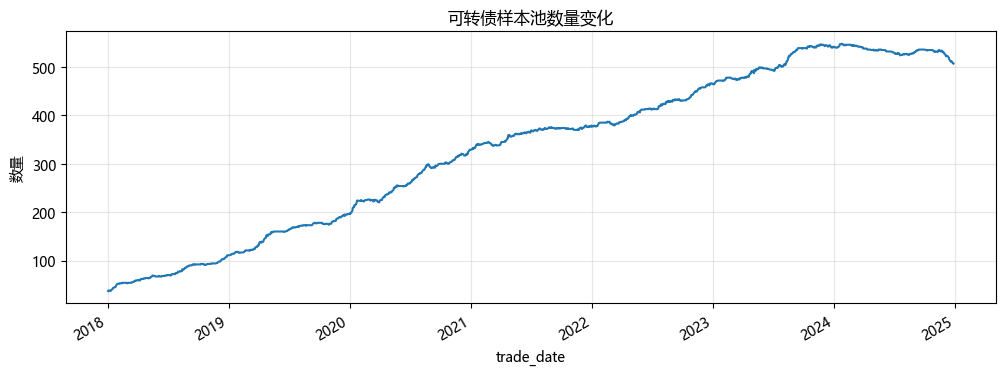

In [3]:
audit_table = pd.DataFrame({
    '字段': df.columns,
    '数据类型': df.dtypes.astype(str).values,
    '缺失率': df.isna().mean().values,
}).sort_values(['缺失率', '字段'], ascending=[False, True]).reset_index(drop=True)

display(audit_table)

daily_cb_count = df.groupby('trade_date')['code'].nunique().rename('可转债数量').sort_index()
daily_count_summary = pd.Series({
    '交易日数': daily_cb_count.shape[0],
    '最小值': daily_cb_count.min(),
    '5%分位数': daily_cb_count.quantile(0.05),
    '25%分位数': daily_cb_count.quantile(0.25),
    '中位数': daily_cb_count.median(),
    '均值': daily_cb_count.mean(),
    '75%分位数': daily_cb_count.quantile(0.75),
    '95%分位数': daily_cb_count.quantile(0.95),
    '最大值': daily_cb_count.max(),
    '标准差': daily_cb_count.std(),
})
display(daily_count_summary.to_frame('统计值'))

plt.figure(figsize=(12, 4))
daily_cb_count.plot()
plt.title('可转债样本池数量变化')
plt.ylabel('数量')
plt.grid(True, alpha=0.3)
plt.show()


In [4]:
field_groups = {
    '价格与收益字段': ['pre_close', 'open', 'high', 'low', 'close', 'close_ma_5', 'bias_5', 'pct_chg', 'pct_chg_5', 'open_pct_chg', 'high_pct_chg', 'low_pct_chg', 'volatility'],
    '可转债估值/溢价字段': ['conv_price', 'conv_value', 'conv_prem', 'dblow', 'ytm', 'bond_prem', 'option_value', 'theory_value', 'theory_bias', 'theory_conv_prem', 'mod_conv_prem'],
    '正股相关字段': ['code_stk', 'name_stk', 'pre_close_stk', 'open_stk', 'high_stk', 'low_stk', 'close_stk', 'pct_chg_stk', 'pct_chg_5_stk', 'alpha_pct_chg_5', 'pe_ttm', 'pb', 'ps_ttm', 'dv_ratio', 'total_share', 'float_share', 'total_mv', 'circ_mv', 'debt_to_assets', 'volatility_stk'],
    '成交额/换手率/流动性字段': ['vol', 'vol_5', 'amount', 'amount_5', 'turnover', 'turnover_5', 'popularity_ranking'],
    '规模字段': ['issue_size', 'remain_size', 'remain_cap', 'cap_mv_rate'],
    '到期、评级、条款、债底相关字段': ['is_call', 'list_date', 'list_days', 'conv_start_date', 'left_conv_start_days', 'conv_end_date', 'left_years', 'rating', 'yy_rating', 'orgform', 'maturity_put_price', 'maturity', 'pure_value'],
}
field_groups = {k: [c for c in v if c in df.columns] for k, v in field_groups.items()}

for k, v in field_groups.items():
    print(f'\n[{k}]')
    print(v)

group_judgement = pd.DataFrame([
    ['价格与收益字段', '适合做收益计算，也可构造短期行为因子；原始价格字段本身不建议直接做横截面选券因子。'],
    ['可转债估值/溢价字段', '最适合做核心因子，尤其是 bond_prem、dblow、theory_bias、conv_prem。'],
    ['正股相关字段', '适合做股债联动因子与风格解释变量，alpha_pct_chg_5、pct_chg_5_stk 可优先考虑。'],
    ['成交额/换手率/流动性字段', '适合做流动性过滤与拥挤度因子，turnover_5、amount 较有代表性。'],
    ['规模字段', '更适合做过滤与风控，remain_size 可作为辅助特征。'],
    ['到期、评级、条款、债底相关字段', '更适合做样本约束和风险控制；pure_value、ytm 可做补充估值因子。'],
], columns=['字段类别', '使用判断'])

display(group_judgement)


[价格与收益字段]
['pre_close', 'open', 'high', 'low', 'close', 'close_ma_5', 'bias_5', 'pct_chg', 'pct_chg_5', 'open_pct_chg', 'high_pct_chg', 'low_pct_chg', 'volatility']

[可转债估值/溢价字段]
['conv_price', 'conv_value', 'conv_prem', 'dblow', 'ytm', 'bond_prem', 'option_value', 'theory_value', 'theory_bias', 'theory_conv_prem', 'mod_conv_prem']

[正股相关字段]
['code_stk', 'name_stk', 'pre_close_stk', 'open_stk', 'high_stk', 'low_stk', 'close_stk', 'pct_chg_stk', 'pct_chg_5_stk', 'alpha_pct_chg_5', 'pe_ttm', 'pb', 'ps_ttm', 'dv_ratio', 'total_share', 'float_share', 'total_mv', 'circ_mv', 'debt_to_assets', 'volatility_stk']

[成交额/换手率/流动性字段]
['vol', 'vol_5', 'amount', 'amount_5', 'turnover', 'turnover_5', 'popularity_ranking']

[规模字段]
['issue_size', 'remain_size', 'remain_cap', 'cap_mv_rate']

[到期、评级、条款、债底相关字段]
['is_call', 'list_date', 'list_days', 'conv_start_date', 'left_conv_start_days', 'conv_end_date', 'left_years', 'rating', 'yy_rating', 'orgform', 'maturity_put_price', 'maturity', 'pure_value']


,字段类别,使用判断
0,价格与收益字段,适合做收益计算，也可构造短期行为因子；原始价格字段本身不建议直接做横截面选券因子。
1,可转债估值/溢价字段,最适合做核心因子，尤其是 bond_prem、dblow、theory_bias、conv_...
2,正股相关字段,适合做股债联动因子与风格解释变量，alpha_pct_chg_5、pct_chg_5_stk...
3,成交额/换手率/流动性字段,适合做流动性过滤与拥挤度因子，turnover_5、amount 较有代表性。
4,规模字段,更适合做过滤与风控，remain_size 可作为辅助特征。
5,到期、评级、条款、债底相关字段,更适合做样本约束和风险控制；pure_value、ytm 可做补充估值因子。


### 样本特征

- 若每日样本数量整体上升，说明研究期内可转债市场在持续扩容，后面的结果需要结合样本池变化理解。
- 若 `code + trade_date` 唯一，说明横截面研究主键干净，可直接用于分组和回测。
- 缺失率较低的估值类、正股联动类和交易类字段，更适合优先拿来做因子测试。


## 样本筛选与预处理

### 过滤规则

可转债横截面研究中，样本筛选会直接影响因子统计性质和回测结果。这里采用几条简单但有金融含义的过滤条件：

- 要求存在实际成交：`amount > 0`
- 要求存在换手：`turnover > 0`
- 要求已进入转股期：`left_conv_start_days <= 0`
- 要求剩余期限不至于过短：`left_years > 0.3`

过滤的目标是提高样本可比性，而不是盲目缩小样本池。


In [5]:
research_df = prepare_research_sample(df)
price_panel = make_panel(research_df, 'close')
fwd_ret_1d = make_forward_return(price_panel, periods=1)

print('研究样本形状:', research_df.shape)
print('研究样本交易日期范围:', research_df['trade_date'].min(), '->', research_df['trade_date'].max())

样本过滤汇总:


,metric,before,after,change,change_pct
0,rows,559940.000000,460994.0000,-98946.000000,-0.176708
1,trade_days,1696.000000,1696.0000,0.000000,0.000000
2,avg_daily_universe,330.153302,271.8125,-58.340802,-0.176708


研究样本形状: (460994, 80)
研究样本交易日期范围: 2018-01-02 00:00:00 -> 2024-12-26 00:00:00


### 过滤结果

- 若过滤后交易日数基本稳定，说明过滤主要是在剔除不适合研究的个券，而不是截断样本期。
- 若日均样本数略有下降但仍保持较大规模，说明过滤后的样本池仍能支撑横截面排序研究。


## 因子设计与经济逻辑

### 候选因子

候选因子共 5 个：`bond_prem`、`dblow`、`alpha_pct_chg_5`、`turnover_5` 和 `theory_bias`。它们分别对应债性溢价、综合便宜度、正股短期联动/反转、交易拥挤度和理论价值偏离，基本覆盖了可转债里常见的几条定价逻辑。

### 最终保留逻辑

候选因子和最终进入组合的因子并不完全相同。单因子和组合敏感性一起看，`turnover_5` 的证据最不一致：`RankIC` 虽然为正，但分组净值和 `long_short` 没有形成同步支持。`theory_bias` 方向没有问题，但单因子力度弱于 `dblow`，而且两者都在刻画便宜度，没有必要同时保留。

所以后面的最终合成不再用 4 因子，而是收成 3 个：`bond_prem`、`dblow` 和 `alpha_pct_chg_5`。这样以后，主逻辑会更清楚：用 `bond_prem` 和 `dblow` 抓低估值转债的价值修复，用 `alpha_pct_chg_5` 修正正股短期追涨后的估值透支或涨幅滞后带来的联动差异。

这些字段在进入检验前统一乘以方向系数，使最终分数满足 **分数越高越好**。


In [6]:
candidate_factor_spec = {
    'bond_prem': -1,
    'dblow': -1,
    'alpha_pct_chg_5': -1,
    'turnover_5': -1,
    'theory_bias': -1,
}

factor_spec = {
    'bond_prem': -1,
    'dblow': -1,
    'alpha_pct_chg_5': -1,
}

factor_plan = pd.DataFrame([
    ['bond_prem', '债性溢价', '低值更优', '取负后分数越高越好', '最终纳入'],
    ['dblow', '综合便宜度', '低值更优', '取负后分数越高越好', '最终纳入'],
    ['alpha_pct_chg_5', '正股 5 日超额涨幅', '低值更优', '取负后分数越高越好', '最终纳入'],
    ['turnover_5', '近 5 日换手率', '低值更优', '取负后分数越高越好', '候选保留，不纳入最终组合'],
    ['theory_bias', '理论价值偏离', '低值更优', '取负后分数越高越好', '候选保留，不纳入最终组合'],
], columns=['因子', '经济含义', '原始方向', '评分方向', '组合角色'])

display(factor_plan)


,因子,经济含义,原始方向,评分方向,组合角色
0,bond_prem,债性溢价,低值更优,取负后分数越高越好,最终纳入
1,dblow,综合便宜度,低值更优,取负后分数越高越好,最终纳入
2,alpha_pct_chg_5,正股 5 日超额涨幅,低值更优,取负后分数越高越好,最终纳入
3,turnover_5,近 5 日换手率,低值更优,取负后分数越高越好,候选保留，不纳入最终组合
4,theory_bias,理论价值偏离,低值更优,取负后分数越高越好,候选保留，不纳入最终组合


### 因子设计结论

这一部分主要交代因子含义和方向，不追求复杂。只要字段来源清楚、方向能统一，后面就可以放到同一套检验里比较。


## 单因子检验

### 检验口径

先看候选因子本身能不能把样本分开。正文只放最终组合里的 3 个核心因子：`dblow`、`bond_prem` 和 `alpha_pct_chg_5`。`turnover_5` 仍然保留在 notebook 里做候选因子检验，但只放到附录补充里，不再占正文主图位置。

检验方式保留两类：

- 分组回测：每天按横截面分成 5 组，观察 `G1-G5` 和 `long_short`。
- IC / RankIC / IR：看因子排序和未来收益排序是不是大致一致。研报和课程材料里通常会把 IC 大于 0.02 作为相关性较显著的经验线，但这里仍需要结合分组图和组合增量一起判断。

前面已经把因子统一成 **分数越高越好**，所以这里的多空组合固定写成：**`long_short = G5 - G1`**。左图统一展示 `G1-G5`，避免只看头尾两组把图说满。



===== dblow =====


,dblow
IC mean,0.020773
IC std,0.175338
ICIR,0.118472
RankIC mean,0.030131
RankIC std,0.177387
RankICIR,0.169863


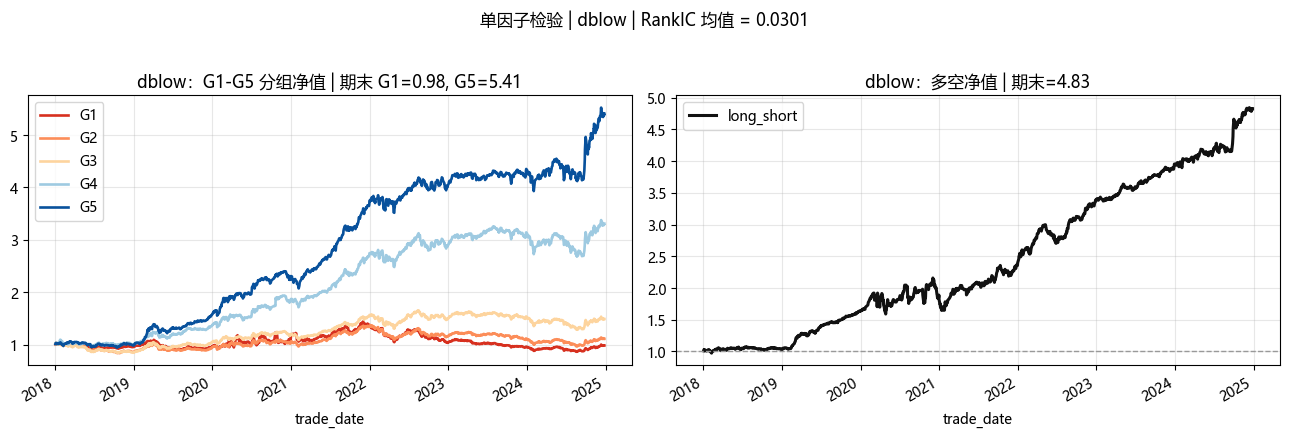

结果解读：从当前样本看，dblow 这张图的分层更清楚，视觉证据也更强。它不是统计值最高的单因子，但作为第二条估值线，纳入后组合增量更明确。



===== bond_prem =====


,bond_prem
IC mean,0.018473
IC std,0.249315
ICIR,0.074096
RankIC mean,0.052098
RankIC std,0.253353
RankICIR,0.205635


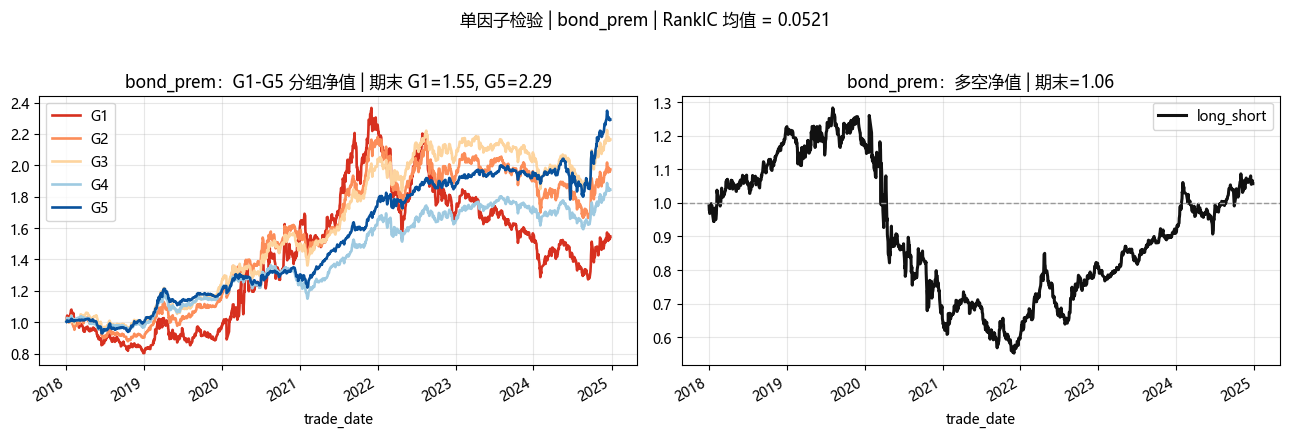

结果解读：bond_prem 的 RankIC mean 仍然更高，是更稳的统计主证据。但图上分层没有长期稳定压开，尤其 2021-2022 这一段 G1 明显跑赢 G5，long_short 也不是持续上行，所以这里只能保守地说期末 G5 高于 G1，且 RankIC 为正。



===== alpha_pct_chg_5 =====


,alpha_pct_chg_5
IC mean,0.029478
IC std,0.157922
ICIR,0.186660
RankIC mean,0.031935
RankIC std,0.140988
RankICIR,0.226508


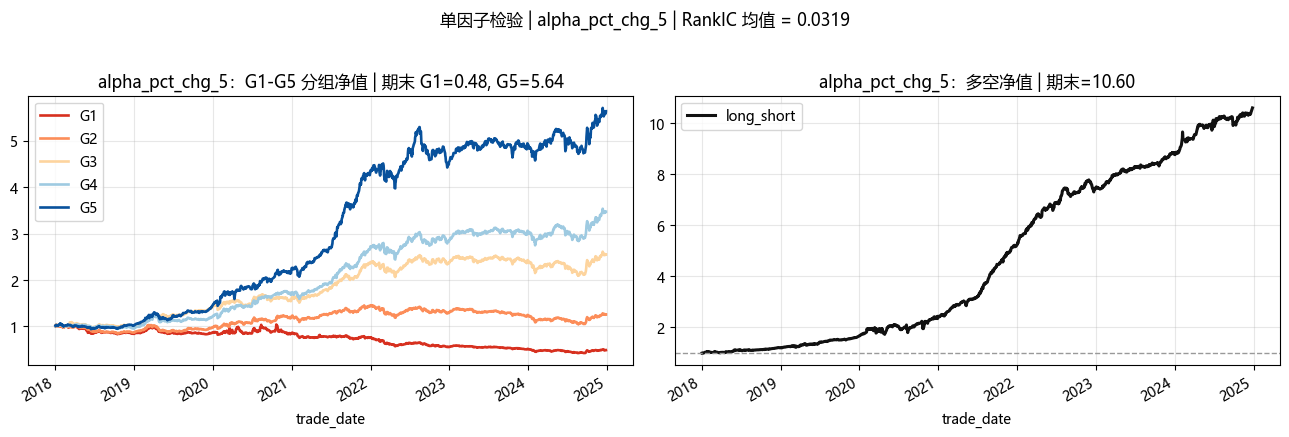

结果解读：alpha_pct_chg_5 的 RankIC mean 约为 0.0319，单因子不是最强，但方向和统计值都不差。该因子在代码中按低值更优处理，不能解释为高动量追涨因子，更适合作为正股短期联动/反转修正维度，补充估值类因子之外的信息。



===== turnover_5 =====


,turnover_5
IC mean,0.016643
IC std,0.253409
ICIR,0.065675
RankIC mean,0.030509
RankIC std,0.230223
RankICIR,0.132521


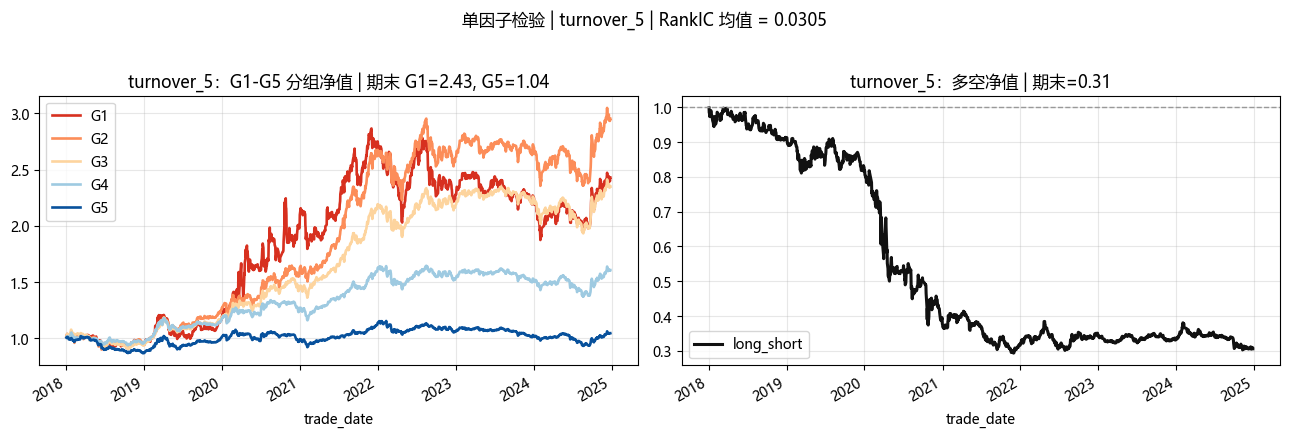

结果解读：turnover_5 的单因子图和统计结果不够一致，因此没有进入最终组合。


In [7]:
for factor_name in ['dblow', 'bond_prem', 'alpha_pct_chg_5', 'turnover_5']:
    factor_sign = candidate_factor_spec[factor_name]
    factor_score = normalize_cross_section(make_panel(research_df, factor_name)) * factor_sign
    ic_df = calc_ic_series(factor_score, fwd_ret_1d)
    group_nav = group_backtest(factor_score, fwd_ret_1d, n_group=5)
    rankic_mean = factor_summary(ic_df)['RankIC mean']
    end_vals = group_nav[['G1', 'G5', 'long_short']].iloc[-1]

    print(f'\n===== {factor_name} =====')
    display(factor_summary(ic_df).to_frame(factor_name))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
    group_nav[['G1', 'G2', 'G3', 'G4', 'G5']].plot(
        ax=axes[0],
        color=['#d7301f', '#fc8d59', '#fdd49e', '#9ecae1', '#08519c'],
        linewidth=1.9,
    )
    axes[0].set_title(
        f"{factor_name}：G1-G5 分组净值 | 期末 G1={end_vals['G1']:.2f}, G5={end_vals['G5']:.2f}"
    )
    axes[0].grid(True, alpha=0.3)

    group_nav[['long_short']].plot(ax=axes[1], color=['#111111'], linewidth=2.2)
    axes[1].axhline(1.0, color='#999999', linestyle='--', linewidth=1)
    axes[1].set_title(f"{factor_name}：多空净值 | 期末={end_vals['long_short']:.2f}")
    axes[1].grid(True, alpha=0.3)

    fig.suptitle(f'单因子检验 | {factor_name} | RankIC 均值 = {rankic_mean:.4f}', y=1.03)
    plt.tight_layout()
    plt.show()

    if factor_name == 'dblow':
        print('结果解读：从当前样本看，dblow 这张图的分层更清楚，视觉证据也更强。它不是统计值最高的单因子，但作为第二条估值线，纳入后组合增量更明确。')
    elif factor_name == 'bond_prem':
        print('结果解读：bond_prem 的 RankIC mean 仍然更高，是更稳的统计主证据。但图上分层没有长期稳定压开，尤其 2021-2022 这一段 G1 明显跑赢 G5，long_short 也不是持续上行，所以这里只能保守地说期末 G5 高于 G1，且 RankIC 为正。')
    elif factor_name == 'alpha_pct_chg_5':
        print(f'结果解读：alpha_pct_chg_5 的 RankIC mean 约为 {rankic_mean:.4f}，单因子不是最强，但方向和统计值都不差。该因子在代码中按低值更优处理，不能解释为高动量追涨因子，更适合作为正股短期联动/反转修正维度，补充估值类因子之外的信息。')
    elif factor_name == 'turnover_5':
        print('结果解读：turnover_5 的单因子图和统计结果不够一致，因此没有进入最终组合。')


In [8]:
single_factor_summary_list = []
for factor_name, sign in candidate_factor_spec.items():
    factor_score = normalize_cross_section(make_panel(research_df, factor_name)) * sign
    ic_df = calc_ic_series(factor_score, fwd_ret_1d)
    s = factor_summary(ic_df)
    s.name = factor_name
    single_factor_summary_list.append(s)

single_factor_summary_df = pd.DataFrame(single_factor_summary_list)
display(single_factor_summary_df.sort_values('RankIC mean', ascending=False))

,IC mean,IC std,ICIR,RankIC mean,RankIC std,RankICIR
bond_prem,0.018473,0.249315,0.074096,0.052098,0.253353,0.205635
alpha_pct_chg_5,0.029478,0.157922,0.186660,0.031935,0.140988,0.226508
turnover_5,0.016643,0.253409,0.065675,0.030509,0.230223,0.132521
dblow,0.020773,0.175338,0.118472,0.030131,0.177387,0.169863
theory_bias,0.026501,0.194080,0.136549,0.016644,0.193026,0.086228


### 候选因子去留总表

单因子图只能说明有没有信息，还不能直接说明最后为什么选这几个因子。所以我把视觉证据、统计证据、替代关系和去留原因放到一张表里，再接一张组合敏感性表，把单因子判断和组合结果连起来看。


In [9]:
candidate_factor_review = []
for factor_name in ['bond_prem', 'dblow', 'alpha_pct_chg_5', 'turnover_5', 'theory_bias']:
    rankic_mean = single_factor_summary_df.loc[factor_name, 'RankIC mean']

    if factor_name == 'bond_prem':
        candidate_factor_review.append({
            '因子名': factor_name,
            '视觉证据': '期末 G5 高于 G1，但分层没有长期稳定压开。',
            '统计证据': f'RankIC mean = {rankic_mean:.4f}，当前样本里最高。',
            '与其他因子的替代关系': '作为债底安全边际补充，与 dblow 同属估值线。',
            '是否纳入最终组合': '是',
            '原因': '统计证据较强，但不作为图形分层主证据。',
        })
    elif factor_name == 'dblow':
        candidate_factor_review.append({
            '因子名': factor_name,
            '视觉证据': '当前样本下分层更清楚，视觉证据更强。',
            '统计证据': f'RankIC mean = {rankic_mean:.4f}。',
            '与其他因子的替代关系': '对应经典双低策略，兼顾低价保护和低溢价弹性。',
            '是否纳入最终组合': '是',
            '原因': '分组图更顺，并且能补充 bond_prem 的估值视角。',
        })
    elif factor_name == 'alpha_pct_chg_5':
        candidate_factor_review.append({
            '因子名': factor_name,
            '视觉证据': '单因子不是最强，但方向和分组结果基本一致。',
            '统计证据': f'RankIC mean = {rankic_mean:.4f}。',
            '与其他因子的替代关系': '按低值更优处理，作为正股短期联动/反转修正维度。',
            '是否纳入最终组合': '是',
            '原因': '作为正股短期联动/反转修正维度保留。',
        })
    elif factor_name == 'turnover_5':
        candidate_factor_review.append({
            '因子名': factor_name,
            '视觉证据': '分组净值和 long_short 与统计结果不够一致。',
            '统计证据': f'RankIC mean = {rankic_mean:.4f}，但和图形证据没有同步支持。',
            '与其他因子的替代关系': '更像行为候选因子，不承担核心排序职责。',
            '是否纳入最终组合': '否',
            '原因': '单因子图和统计证据不够一致，因此剔除。',
        })
    elif factor_name == 'theory_bias':
        candidate_factor_review.append({
            '因子名': factor_name,
            '视觉证据': '方向为正，但视觉区分度弱于 dblow。',
            '统计证据': f'RankIC mean = {rankic_mean:.4f}。',
            '与其他因子的替代关系': '与 dblow 都描述便宜度，重复度更高。',
            '是否纳入最终组合': '否',
            '原因': '力度弱于 dblow，且二者重合较多。',
        })

candidate_factor_review_df = pd.DataFrame(candidate_factor_review).set_index('因子名')
display(candidate_factor_review_df)

amount_panel_tmp = make_panel(research_df, 'amount')
amount_q20_mask_tmp = apply_cross_section_quantile_filter(amount_panel_tmp, quantile=0.20, keep='ge')
benchmark_weight_tmp = price_panel.notna().astype(float)
benchmark_weight_tmp = benchmark_weight_tmp.div(benchmark_weight_tmp.sum(axis=1), axis=0)
benchmark_ret_tmp = (benchmark_weight_tmp * fwd_ret_1d).sum(axis=1)

factor_combo_specs = {
    '四因子候选组合': {
        'bond_prem': -1,
        'alpha_pct_chg_5': -1,
        'turnover_5': -1,
        'theory_bias': -1,
    },
    '去掉 turnover_5': {
        'bond_prem': -1,
        'alpha_pct_chg_5': -1,
        'theory_bias': -1,
    },
    '三因子主组合': {
        'bond_prem': -1,
        'alpha_pct_chg_5': -1,
        'dblow': -1,
    },
}

factor_combo_compare = []
for name, spec in factor_combo_specs.items():
    combo_score = build_composite_score(research_df, factor_spec=spec, q=0.02).where(amount_q20_mask_tmp)
    combo_result = topn_buffer_equal_weight_backtest(
        score_panel=combo_score,
        fwd_ret_panel=fwd_ret_1d,
        buy_n=10,
        sell_n=15,
        rebalance_freq=OFFICIAL_REBALANCE_FREQ,
        fee_rate=OFFICIAL_FEE_RATE,
    )
    combo_snapshot = make_strategy_snapshot(combo_result, benchmark_ret_tmp)
    combo_snapshot.name = name
    factor_combo_compare.append(combo_snapshot)

factor_combo_compare_df = pd.DataFrame(factor_combo_compare)
display(factor_combo_compare_df[['annual_return', 'sharpe', 'max_drawdown', 'avg_turnover', 'excess_total_return', 'information_ratio']])


,视觉证据,统计证据,与其他因子的替代关系,是否纳入最终组合,原因
因子名,,,,,
bond_prem,期末 G5 高于 G1，但分层没有长期稳定压开。,RankIC mean = 0.0521，当前样本里最高。,作为债底安全边际补充，与 dblow 同属估值线。,是,统计证据较强，但不作为图形分层主证据。
dblow,当前样本下分层更清楚，视觉证据更强。,RankIC mean = 0.0301。,对应经典双低策略，兼顾低价保护和低溢价弹性。,是,分组图更顺，并且能补充 bond_prem 的估值视角。
alpha_pct_chg_5,单因子不是最强，但方向和分组结果基本一致。,RankIC mean = 0.0319。,按低值更优处理，作为正股短期联动/反转修正维度。,是,作为正股短期联动/反转修正维度保留。
turnover_5,分组净值和 long_short 与统计结果不够一致。,RankIC mean = 0.0305，但和图形证据没有同步支持。,更像行为候选因子，不承担核心排序职责。,否,单因子图和统计证据不够一致，因此剔除。
theory_bias,方向为正，但视觉区分度弱于 dblow。,RankIC mean = 0.0166。,与 dblow 都描述便宜度，重复度更高。,否,力度弱于 dblow，且二者重合较多。


,annual_return,sharpe,max_drawdown,avg_turnover,excess_total_return,information_ratio
四因子候选组合,0.177524,1.091158,-0.345334,0.148542,0.559284,0.659368
去掉 turnover_5,0.268473,1.432798,-0.271851,0.151564,1.651267,1.178568
三因子主组合,0.281998,1.486607,-0.181463,0.169340,1.843002,1.196603


### 单因子筛选结论

- `dblow` 这张图的分层更顺，`long_short` 也更容易读出一致方向，因此它更适合作为第二条估值线放进组合。
- `bond_prem` 的统计结果最稳，但图上不能写得太满。更稳妥的说法是：期末 `G5` 高于 `G1`，而且 `RankIC` 为正；至于分层是否长期清楚、`long_short` 是否很强，图形本身并不支持这样写。
- `alpha_pct_chg_5` 的 `RankIC mean` 约为 `0.0319`，单因子不算最强。当前按低值更优处理，更适合解释为短期联动/反转修正信息。放回组合以后，它的保留理由会更充分。
- `turnover_5` 只保留一句交代：单因子图和统计结果不够一致，因此不再进入最终组合。


## 因子相关性分析

### 本节目的

单因子看完后，还要确认这些因子是不是都在说同一件事。这里用日度截面相关系数，再对时间取平均，粗略看一下候选因子之间的关系。

相关性不需要追求特别低，关键是不要简单重复。只要不同因子提供的信息不完全重合，多因子合成就还有意义。


,bond_prem,dblow,alpha_pct_chg_5,turnover_5,theory_bias
bond_prem,1.000,0.244,-0.015,0.527,0.152
dblow,0.244,1.000,0.079,0.268,0.566
alpha_pct_chg_5,-0.015,0.079,1.000,-0.066,0.082
turnover_5,0.527,0.268,-0.066,1.000,0.086
theory_bias,0.152,0.566,0.082,0.086,1.000


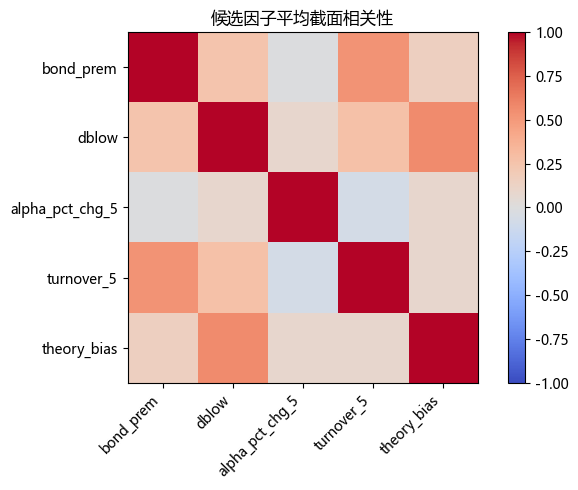

In [10]:
factor_score_panels = {}
for factor_name, sign in candidate_factor_spec.items():
    factor_score_panels[factor_name] = normalize_cross_section(make_panel(research_df, factor_name)) * sign

corr_dates = price_panel.index
corr_accumulator = []
factor_names = list(candidate_factor_spec.keys())

for dt in corr_dates:
    daily_df = pd.DataFrame({name: factor_score_panels[name].loc[dt] for name in factor_names}).dropna()
    if len(daily_df) >= 10:
        corr_accumulator.append(daily_df.corr())

avg_corr = sum(corr_accumulator) / len(corr_accumulator)
display(avg_corr.round(3))

plt.figure(figsize=(7, 5))
plt.imshow(avg_corr.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(avg_corr.columns)), avg_corr.columns, rotation=45, ha='right')
plt.yticks(range(len(avg_corr.index)), avg_corr.index)
plt.title('候选因子平均截面相关性')
plt.tight_layout()
plt.show()

### 相关性结论

- 便宜度相关因子之间确实有重叠，`dblow` 和 `theory_bias` 的平均相关系数大约是 `0.566`。
- `bond_prem` 和 `turnover_5` 也不是完全独立，说明估值和拥挤度在当前样本里会有一部分重合。
- `alpha_pct_chg_5` 和其他几项的相关性低一些，说明它补充了估值之外的正股短期联动/反转信息。
- 最终没有继续保留 `theory_bias` 和 `turnover_5`。前者和 `dblow` 重合更多，但单因子和组合敏感性都弱一些；后者则是单因子图和最终方向不够一致。


## 多因子合成方法

### 合成逻辑

单因子各自都有信息，但真正拿去做组合时，还要把重复度和经济含义一起看。这里最终采用 3 因子等权合成：`bond_prem`、`dblow` 和 `alpha_pct_chg_5`。

这 3 个因子的定位比较清楚：

1. `dblow` 对应经典双低思路，兼顾低价保护和低溢价弹性；
2. `alpha_pct_chg_5` 按低值更优处理，作为正股短期联动/反转修正因子；
3. `bond_prem` 作为债底安全边际补充，统计证据较强，但不写成视觉分层最强的核心因子。

### 评分口径

1. 对每个因子按日做截面去极值；
2. 按日做截面 z-score 标准化；
3. 按预设方向乘以 `+1 / -1`；
4. 将纳入最终组合的 3 个因子等权平均，得到综合分数。

合成后的综合分数继续满足：**分数越高越好**。

### 与主策略的关系

组合构建并不止停在 3 因子等权 Top10 上，后面还会叠加 `amount q20` 可交易性约束、`Top10 / Top15` 缓冲区执行规则和正式手续费 `fee_rate = 0.002`。这样以后，主线更像“在可交易样本里找低估值、受正股带动但不过热的转债”。


In [11]:
composite_score = build_composite_score(research_df, factor_spec=factor_spec, q=0.02)

amount_panel = make_panel(research_df, 'amount')
amount_q10_mask = apply_cross_section_quantile_filter(amount_panel, quantile=0.10, keep='ge')
amount_q20_mask = apply_cross_section_quantile_filter(amount_panel, quantile=0.20, keep='ge')
amount_q30_mask = apply_cross_section_quantile_filter(amount_panel, quantile=0.30, keep='ge')
amount_q40_mask = apply_cross_section_quantile_filter(amount_panel, quantile=0.40, keep='ge')
amount_q50_mask = apply_cross_section_quantile_filter(amount_panel, quantile=0.50, keep='ge')
amount_q60_mask = apply_cross_section_quantile_filter(amount_panel, quantile=0.60, keep='ge')

strategy_score_q10 = composite_score.where(amount_q10_mask)
strategy_score_q20 = composite_score.where(amount_q20_mask)
strategy_score_q30 = composite_score.where(amount_q30_mask)
strategy_score_q40 = composite_score.where(amount_q40_mask)
strategy_score_q50 = composite_score.where(amount_q50_mask)
strategy_score_q60 = composite_score.where(amount_q60_mask)

display(composite_score.iloc[:5, :5])


code,110030.SH,110031.SH,110032.SH,110033.SH,110034.SH
trade_date,,,,,
2018-01-02,0.388751,-1.168079,0.022881,-0.085069,0.269790
2018-01-03,0.511687,-1.046665,-0.594131,-0.363471,-0.062097
2018-01-04,0.703826,-0.903547,-0.594478,-0.517305,-0.385859
2018-01-05,0.919623,-0.415504,-0.826191,-0.671985,-0.396011
2018-01-08,0.902544,-0.689252,-0.613250,-0.598763,-0.371462


### 综合评分口径

这一段主要是固定组合实际使用的评分口径：先用 `bond_prem + dblow + alpha_pct_chg_5` 合成分数，再用 `amount q20` 过滤把成交额最差的一批样本拿掉。后面的主回测统一采用正式成本口径 **`fee_rate = 0.002`**，稳健性测试再单独展示低费率和高费率下的变化。


## TopN 组合回测

### 主策略定义

从这里开始，正式主策略按下面的规则回测：

- 三因子评分：`bond_prem + dblow + alpha_pct_chg_5`
- `amount q20` 可交易性过滤
- BW 双周调仓
- `Top10` 买入，跌出 `Top15` 卖出
- 在最终持仓内部按综合评分排名加权
- 正式交易成本：`fee_rate = 0.002`

### 基准说明

基准仍为研究样本等权组合，不计手续费，用于衡量横截面选券带来的超额收益。


,等权 BW 缓冲,缓冲排名加权 BW,无缓冲 Top10 排名加权
annual_return,0.281998,0.368615,0.378265
sharpe,1.486607,1.758304,1.779634
max_drawdown,-0.181463,-0.182464,-0.181878
avg_turnover,0.169340,0.181447,0.184681
excess_total_return,1.843002,3.482913,3.707050
information_ratio,1.196603,1.435558,1.448632


,等权 BW 缓冲,缓冲排名加权 BW
full_annual_return,0.281998,0.368615
full_sharpe,1.486607,1.758304
full_max_drawdown,-0.181463,-0.182464
full_avg_turnover,0.169340,0.181447
full_excess_total_return,1.843002,3.482913
full_information_ratio,1.196603,1.435558
fee003_annual_return,0.230008,0.309235
fee003_sharpe,1.208811,1.470837
fee003_max_drawdown,-0.189199,-0.190223
stage2324_annual_return,0.236587,0.350320


,passed
full_sample_return_sharpe_ir,True
fee_003_return_sharpe_drawdown,True
stage_2023_2024,True
rolling_validation,True


最终主策略: 缓冲排名加权 BW 主策略


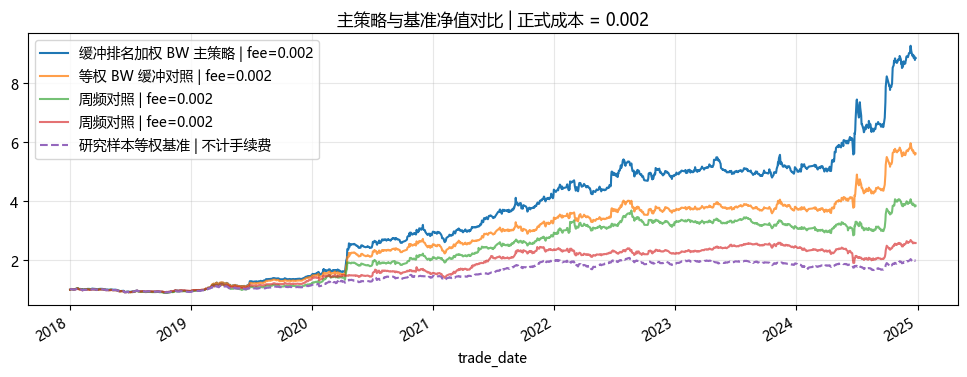

In [12]:
baseline_equal_result = topn_equal_weight_backtest(
    score_panel=composite_score,
    fwd_ret_panel=fwd_ret_1d,
    top_n=10,
    rebalance_freq=OFFICIAL_REBALANCE_FREQ,
    fee_rate=OFFICIAL_FEE_RATE,
)

frequency_results = {}
for freq in ['D', 'W', 'BW', 'M']:
    frequency_results[freq] = topn_buffer_equal_weight_backtest(
        score_panel=strategy_score_q20,
        fwd_ret_panel=fwd_ret_1d,
        buy_n=10,
        sell_n=15,
        rebalance_freq=freq,
        fee_rate=OFFICIAL_FEE_RATE,
    )

daily_result = frequency_results['D']
weekly_result = frequency_results['W']
equal_bw_result = frequency_results['BW']
bw_result = equal_bw_result
monthly_result = frequency_results['M']

unbuffered_rank_weight_result = topn_rank_weight_backtest(
    score_panel=strategy_score_q20,
    fwd_ret_panel=fwd_ret_1d,
    top_n=10,
    rebalance_freq=OFFICIAL_REBALANCE_FREQ,
    fee_rate=OFFICIAL_FEE_RATE,
)

buffer_rank_weight_result = topn_buffer_rank_weight_backtest(
    score_panel=strategy_score_q20,
    fwd_ret_panel=fwd_ret_1d,
    buy_n=10,
    sell_n=15,
    rebalance_freq=OFFICIAL_REBALANCE_FREQ,
    fee_rate=OFFICIAL_FEE_RATE,
)

benchmark_weight = price_panel.notna().astype(float)
benchmark_weight = benchmark_weight.div(benchmark_weight.sum(axis=1), axis=0)
benchmark_ret = (benchmark_weight * fwd_ret_1d).sum(axis=1)
benchmark_nav = (1 + benchmark_ret.fillna(0)).cumprod()
benchmark_df = pd.DataFrame({'ret': benchmark_ret, 'nav': benchmark_nav})

strategy_candidate_compare = pd.DataFrame({
    '等权 BW 缓冲': make_strategy_snapshot(equal_bw_result, benchmark_df['ret']),
    '缓冲排名加权 BW': make_strategy_snapshot(buffer_rank_weight_result, benchmark_df['ret']),
    '无缓冲 Top10 排名加权': make_strategy_snapshot(unbuffered_rank_weight_result, benchmark_df['ret']),
})
display(strategy_candidate_compare.loc[['annual_return', 'sharpe', 'max_drawdown', 'avg_turnover', 'excess_total_return', 'information_ratio']])

# Validation gate: only promote buffered rank weighting when all checks pass.
equal_bw_fee003_result = topn_buffer_equal_weight_backtest(
    score_panel=strategy_score_q20,
    fwd_ret_panel=fwd_ret_1d,
    buy_n=10,
    sell_n=15,
    rebalance_freq=OFFICIAL_REBALANCE_FREQ,
    fee_rate=0.003,
)
buffer_rank_fee003_result = topn_buffer_rank_weight_backtest(
    score_panel=strategy_score_q20,
    fwd_ret_panel=fwd_ret_1d,
    buy_n=10,
    sell_n=15,
    rebalance_freq=OFFICIAL_REBALANCE_FREQ,
    fee_rate=0.003,
)

equal_bw_full = make_strategy_snapshot(equal_bw_result, benchmark_df['ret'])
buffer_rank_full = make_strategy_snapshot(buffer_rank_weight_result, benchmark_df['ret'])
equal_bw_fee003 = make_strategy_snapshot(equal_bw_fee003_result, benchmark_df['ret'])
buffer_rank_fee003 = make_strategy_snapshot(buffer_rank_fee003_result, benchmark_df['ret'])

stage_gate_mask = equal_bw_result.index > pd.Timestamp('2022-12-31')
equal_stage_2324 = make_strategy_snapshot(equal_bw_result.loc[stage_gate_mask], benchmark_df['ret'].loc[stage_gate_mask])
buffer_rank_stage_2324 = make_strategy_snapshot(buffer_rank_weight_result.loc[stage_gate_mask], benchmark_df['ret'].loc[stage_gate_mask])

_, equal_bw_rolling_summary = run_rolling_train_validate(
    candidate_results={'等权 BW 缓冲': equal_bw_result},
    benchmark_ret=benchmark_df['ret'],
    train_years=3,
)
_, buffer_rank_rolling_summary = run_rolling_train_validate(
    candidate_results={'缓冲排名加权 BW': buffer_rank_weight_result},
    benchmark_ret=benchmark_df['ret'],
    train_years=3,
)

def _not_worse_drawdown(candidate_mdd: float, baseline_mdd: float, tolerance: float = 0.03) -> bool:
    return candidate_mdd >= baseline_mdd - tolerance

validation_gate_checks = pd.Series({
    'full_sample_return_sharpe_ir': (
        buffer_rank_full['annual_return'] >= equal_bw_full['annual_return'] and
        buffer_rank_full['sharpe'] >= equal_bw_full['sharpe'] and
        buffer_rank_full['information_ratio'] >= equal_bw_full['information_ratio'] and
        _not_worse_drawdown(buffer_rank_full['max_drawdown'], equal_bw_full['max_drawdown'])
    ),
    'fee_003_return_sharpe_drawdown': (
        buffer_rank_fee003['annual_return'] >= equal_bw_fee003['annual_return'] and
        buffer_rank_fee003['sharpe'] >= equal_bw_fee003['sharpe'] and
        _not_worse_drawdown(buffer_rank_fee003['max_drawdown'], equal_bw_fee003['max_drawdown'])
    ),
    'stage_2023_2024': (
        buffer_rank_stage_2324['annual_return'] > 0 and
        buffer_rank_stage_2324['sharpe'] >= equal_stage_2324['sharpe'] * 0.9 and
        _not_worse_drawdown(buffer_rank_stage_2324['max_drawdown'], equal_stage_2324['max_drawdown'])
    ),
    'rolling_validation': (
        buffer_rank_rolling_summary['annual_return'] >= equal_bw_rolling_summary['annual_return'] * 0.9 and
        buffer_rank_rolling_summary['sharpe'] >= equal_bw_rolling_summary['sharpe'] * 0.9 and
        buffer_rank_rolling_summary['information_ratio'] >= equal_bw_rolling_summary['information_ratio'] * 0.9 and
        _not_worse_drawdown(buffer_rank_rolling_summary['max_drawdown'], equal_bw_rolling_summary['max_drawdown'])
    ),
})

validation_gate_table = pd.DataFrame({
    '等权 BW 缓冲': pd.concat([
        equal_bw_full.add_prefix('full_'),
        equal_bw_fee003.add_prefix('fee003_'),
        equal_stage_2324.add_prefix('stage2324_'),
        equal_bw_rolling_summary.add_prefix('rolling_'),
    ]),
    '缓冲排名加权 BW': pd.concat([
        buffer_rank_full.add_prefix('full_'),
        buffer_rank_fee003.add_prefix('fee003_'),
        buffer_rank_stage_2324.add_prefix('stage2324_'),
        buffer_rank_rolling_summary.add_prefix('rolling_'),
    ]),
})
display(validation_gate_table.loc[
    [
        'full_annual_return', 'full_sharpe', 'full_max_drawdown', 'full_avg_turnover', 'full_excess_total_return', 'full_information_ratio',
        'fee003_annual_return', 'fee003_sharpe', 'fee003_max_drawdown',
        'stage2324_annual_return', 'stage2324_sharpe', 'stage2324_max_drawdown',
        'rolling_annual_return', 'rolling_sharpe', 'rolling_max_drawdown', 'rolling_excess_total_return', 'rolling_information_ratio',
    ]
])
display(validation_gate_checks.to_frame('passed'))

buffer_rank_weight_passed = bool(validation_gate_checks.all())
if buffer_rank_weight_passed:
    main_result = buffer_rank_weight_result
    main_strategy_key = 'buffer_rank_weight_bw'
    main_strategy_label = '缓冲排名加权 BW 主策略'
else:
    main_result = equal_bw_result
    main_strategy_key = 'equal_weight_bw'
    main_strategy_label = '等权 BW 缓冲主策略'

print('最终主策略:', main_strategy_label)

plt.figure(figsize=(12, 4))
main_result['nav'].plot(label=f'{main_strategy_label} | fee=0.002')
if main_strategy_key != 'equal_weight_bw':
    equal_bw_result['nav'].plot(label='等权 BW 缓冲对照 | fee=0.002', alpha=0.75)
weekly_result['nav'].plot(label='周频对照 | fee=0.002', alpha=0.65)
monthly_result['nav'].plot(label='周频对照 | fee=0.002', alpha=0.65)
benchmark_df['nav'].plot(label='研究样本等权基准 | 不计手续费', linestyle='--')
plt.title('主策略与基准净值对比 | 正式成本 = 0.002')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### 净值图观察

净值图里，正式成本下双周主策略仍然高于研究样本等权基准。周频和月频保留为对照，主要是看调仓周期变化会怎样影响结果。


## 策略绩效评估

### 评估重点

后文如果没有特别说明，主策略默认指 **3 因子（`bond_prem + dblow + alpha_pct_chg_5`）+ `amount q20` 过滤 + 双周 BW Top10 买入 / 跌出 Top15 卖出 + 等权持仓 + `fee_rate = 0.002`**。

这一节主要看四件事：

- 主策略年化收益、夏普、最大回撤和超额是否仍能站住；
- 正式成本口径相对低费率口径压缩了多少收益；
- 年度收益和年度最大回撤是否集中在少数年份；
- 多空 20% 对冲验证是否支持综合评分的横截面排序。

基准仍然不计手续费，作用是衡量横截面选券究竟带来了多少额外收益。


,main_strategy,equal_bw_contrast,weekly_contrast,monthly_contrast,equal_weight_benchmark
total_return,7.856612,4.622178,2.853350,1.589112,0.999274
annual_return,0.368615,0.281998,0.214181,0.146672,0.104806
annual_vol,0.209643,0.189692,0.187210,0.161545,0.122569
sharpe,1.758304,1.486607,1.144068,0.907932,0.855077
max_drawdown,-0.182464,-0.181463,-0.227864,-0.262874,-0.198149
calmar,2.020208,1.554025,0.939952,0.557954,0.528923
win_rate,0.527123,0.526533,0.514741,0.523585,0.535967
avg_turnover,0.181447,0.169340,0.327501,0.080902,NaN


,total_return,annual_return,annual_vol,sharpe,max_drawdown,calmar,win_rate,avg_turnover,excess_total_return,information_ratio
D,-0.411894,-0.073529,0.172797,-0.425520,-0.592495,-0.124100,0.465212,0.764485,-0.706762,-1.359519
W,2.853350,0.214181,0.187210,1.144068,-0.227864,0.939952,0.514741,0.327501,0.938858,0.774164
BW,4.622178,0.281998,0.189692,1.486607,-0.181463,1.554025,0.526533,0.169340,1.843002,1.196603
M,1.589112,0.146672,0.161545,0.907932,-0.262874,0.557954,0.523585,0.080902,0.291084,0.391443


,main_strategy,weekly_contrast,monthly_contrast,equal_bw_contrast
excess_total_return,3.482913,0.938858,0.291084,1.843002
information_ratio,1.435558,0.774164,0.391443,1.196603


main_strategy                                     weekly_contrast                                     monthly_contrast                                     equal_weight_benchmark            \
     annual_return    sharpe max_drawdown avg_turnover   annual_return    sharpe max_drawdown avg_turnover    annual_return    sharpe max_drawdown avg_turnover          annual_return    sharpe   
year                                                                                                                                                                                               
2018     -0.041923 -0.481623    -0.143934     0.119114       -0.052769 -0.601292    -0.153214     0.159288        -0.031331 -0.366835    -0.120564     0.041642              -0.070791 -0.853883   
2019      0.564707  3.781080    -0.111785     0.169231        0.283570  2.139143    -0.155578     0.302053         0.418434  3.125085    -0.112224     0.066056               0.253644  2.227768   
2020      0.987704  2.965290    -0.118399     0.194314        0.738225  2.456295    -0.104274     0.352001         0.146990  0.697940    -0.130144     0.090909               0.262608  1.570284   
2021      0.481933  2.672928    -0.117937     0.201011        0.395794  2.412799    -0.084220     0.368300         0.512584  2.906683    -0.104795     0.090273               0.369951  3.273644   
2022      0.115212  0.601324    -0.133842     0.199825        0.122033  0.627679    -0.150372     0.378715        -0.063744 -0.411631    -0.123223     0.088580              -0.066560 -0.491607   
2023      0.050081  0.382429    -0.124774     0.190562       -0.042785 -0.413324    -0.111713     0.368470         0.115228  1.174373    -0.065419     0.093839               0.011014  0.141982   
2024      0.741892  2.623288    -0.148801     0.196485        0.226227  0.971558    -0.135195     0.364777         0.043729  0.198495    -0.218398     0.095397               0.054084  0.381890   

                               equal_bw_contrast                                      
     max_drawdown avg_turnover     annual_return    sharpe max_drawdown avg_turnover  
year                                                                                  
2018    -0.131450          NaN         -0.044157 -0.499371    -0.144713     0.086783  
2019    -0.120556          NaN          0.522794  3.637022    -0.120723     0.149333  
2020    -0.066627          NaN          0.753023  2.531390    -0.111967     0.188103  
2021    -0.096352          NaN          0.357196  2.080847    -0.118457     0.192618  
2022    -0.153585          NaN          0.072394  0.408485    -0.120016     0.195041  
2023    -0.080648          NaN          0.031782  0.286593    -0.094905     0.183471  
2024    -0.119042          NaN          0.485416  1.956406    -0.130262     0.190630

,main_strategy,weekly_contrast,monthly_contrast,equal_weight_benchmark,equal_bw_contrast
trade_date,,,,,
2018,-0.143934,-0.153214,-0.120564,-0.131450,-0.144713
2019,-0.111785,-0.155578,-0.112224,-0.120556,-0.120723
2020,-0.118399,-0.104274,-0.130144,-0.066627,-0.111967
2021,-0.117937,-0.084220,-0.104795,-0.096352,-0.118457
2022,-0.133842,-0.150372,-0.123223,-0.153585,-0.120016
2023,-0.124774,-0.111713,-0.065419,-0.080648,-0.094905
2024,-0.148801,-0.135195,-0.218398,-0.119042,-0.130262


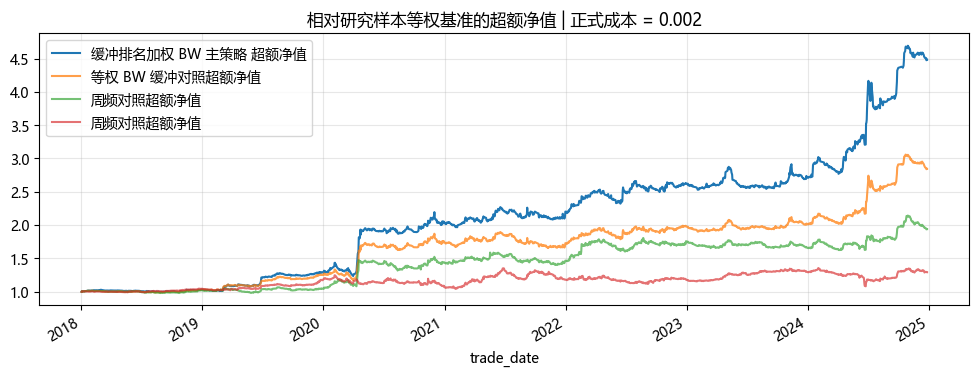

,top_bottom_20pct
total_return,8.263237
annual_return,0.377483
annual_vol,0.195077
sharpe,1.935043
max_drawdown,-0.314820
calmar,1.199045
win_rate,0.590212
avg_turnover,NaN


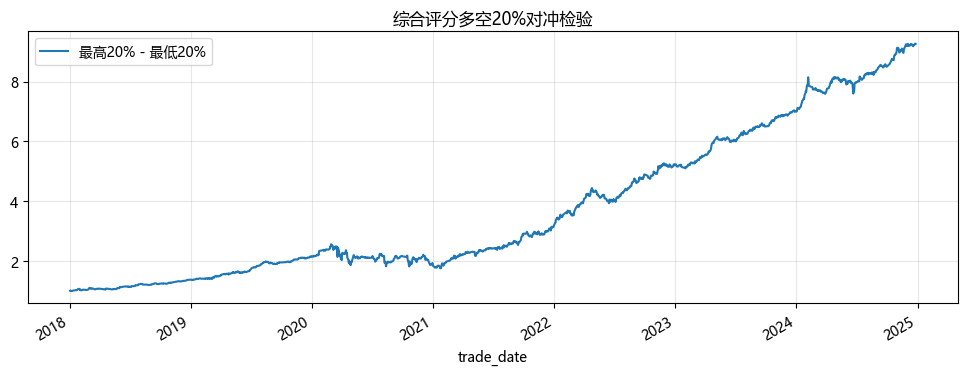

In [13]:
perf_columns = [
    summarize_performance(main_result['net_ret'], main_result['nav'], main_result['turnover']).rename('main_strategy'),
]
if main_strategy_key != 'equal_weight_bw':
    perf_columns.append(summarize_performance(equal_bw_result['net_ret'], equal_bw_result['nav'], equal_bw_result['turnover']).rename('equal_bw_contrast'))
perf_columns.extend([
    summarize_performance(weekly_result['net_ret'], weekly_result['nav'], weekly_result['turnover']).rename('weekly_contrast'),
    summarize_performance(monthly_result['net_ret'], monthly_result['nav'], monthly_result['turnover']).rename('monthly_contrast'),
    summarize_performance(benchmark_df['ret'], benchmark_df['nav'], None).rename('equal_weight_benchmark'),
])
perf_table = pd.concat(perf_columns, axis=1)
display(perf_table)

frequency_perf_rows = []
for freq, result in frequency_results.items():
    perf = summarize_performance(result['net_ret'], result['nav'], result['turnover'])
    excess_ret = result['net_ret'] - benchmark_df['ret']
    excess_nav = (1 + excess_ret.fillna(0)).cumprod()
    perf['excess_total_return'] = excess_nav.iloc[-1] - 1
    perf['information_ratio'] = calc_ir(excess_ret)
    perf.name = freq
    frequency_perf_rows.append(perf)
frequency_sensitivity_df = pd.DataFrame(frequency_perf_rows)
frequency_sensitivity_df = frequency_sensitivity_df.loc[['D', 'W', 'BW', 'M']]
display(frequency_sensitivity_df)

main_excess_ret = main_result['net_ret'] - benchmark_df['ret']
equal_bw_excess_ret = equal_bw_result['net_ret'] - benchmark_df['ret']
weekly_excess_ret = weekly_result['net_ret'] - benchmark_df['ret']
monthly_excess_ret = monthly_result['net_ret'] - benchmark_df['ret']
main_excess_nav = (1 + main_excess_ret.fillna(0)).cumprod()
equal_bw_excess_nav = (1 + equal_bw_excess_ret.fillna(0)).cumprod()
weekly_excess_nav = (1 + weekly_excess_ret.fillna(0)).cumprod()
monthly_excess_nav = (1 + monthly_excess_ret.fillna(0)).cumprod()

excess_table_data = {
    'main_strategy': {
        'excess_total_return': main_excess_nav.iloc[-1] - 1,
        'information_ratio': calc_ir(main_excess_ret),
    },
    'weekly_contrast': {
        'excess_total_return': weekly_excess_nav.iloc[-1] - 1,
        'information_ratio': calc_ir(weekly_excess_ret),
    },
    'monthly_contrast': {
        'excess_total_return': monthly_excess_nav.iloc[-1] - 1,
        'information_ratio': calc_ir(monthly_excess_ret),
    },
}
if main_strategy_key != 'equal_weight_bw':
    excess_table_data['equal_bw_contrast'] = {
        'excess_total_return': equal_bw_excess_nav.iloc[-1] - 1,
        'information_ratio': calc_ir(equal_bw_excess_ret),
    }
excess_table = pd.DataFrame(excess_table_data)
display(excess_table)

yearly_perf_table = {
    'main_strategy': calc_yearly_performance(main_result['net_ret'], main_result['turnover']),
    'weekly_contrast': calc_yearly_performance(weekly_result['net_ret'], weekly_result['turnover']),
    'monthly_contrast': calc_yearly_performance(monthly_result['net_ret'], monthly_result['turnover']),
    'equal_weight_benchmark': calc_yearly_performance(benchmark_df['ret'], None),
}
if main_strategy_key != 'equal_weight_bw':
    yearly_perf_table['equal_bw_contrast'] = calc_yearly_performance(equal_bw_result['net_ret'], equal_bw_result['turnover'])
yearly_perf_panel = pd.concat(yearly_perf_table, axis=1)
display(yearly_perf_panel.loc[:, pd.IndexSlice[:, ['annual_return', 'sharpe', 'max_drawdown', 'avg_turnover']]])

yearly_mdd_table_data = {
    'main_strategy': calc_yearly_max_drawdown(main_result['nav']),
    'weekly_contrast': calc_yearly_max_drawdown(weekly_result['nav']),
    'monthly_contrast': calc_yearly_max_drawdown(monthly_result['nav']),
    'equal_weight_benchmark': calc_yearly_max_drawdown(benchmark_df['nav']),
}
if main_strategy_key != 'equal_weight_bw':
    yearly_mdd_table_data['equal_bw_contrast'] = calc_yearly_max_drawdown(equal_bw_result['nav'])
yearly_mdd_table = pd.DataFrame(yearly_mdd_table_data)
display(yearly_mdd_table)

plt.figure(figsize=(12, 4))
main_excess_nav.plot(label=f'{main_strategy_label} 超额净值')
if main_strategy_key != 'equal_weight_bw':
    equal_bw_excess_nav.plot(label='等权 BW 缓冲对照超额净值', alpha=0.75)
weekly_excess_nav.plot(label='周频对照超额净值', alpha=0.65)
monthly_excess_nav.plot(label='周频对照超额净值', alpha=0.65)
plt.title('相对研究样本等权基准的超额净值 | 正式成本 = 0.002')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

hedge_20_result = top_bottom_quantile_hedge_backtest(
    score_panel=strategy_score_q20,
    fwd_ret_panel=fwd_ret_1d,
    quantile=0.20,
)
hedge_20_summary = summarize_performance(
    hedge_20_result['ret'],
    hedge_20_result['nav'],
    turnover=None,
)
display(hedge_20_summary.to_frame('top_bottom_20pct'))

plt.figure(figsize=(12, 4))
hedge_20_result['nav'].plot(label='最高20% - 最低20%')
plt.title('综合评分多空20%对冲检验')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### 主策略绩效结论

正式成本 `fee_rate=0.002` 下，主策略采用 BW 双周调仓、`Top10 / Top15` 缓冲规则，并在当前持仓内部按排名加权。年化收益约 `36.86%`，夏普约 `1.7583`，最大回撤约 `-18.25%`，超额累计收益约 `348.29%`，信息比率约 `1.4356`。

年度最大回撤表是补充风险视角，不替代全样本最大回撤。它用于观察回撤是否集中在特定年份，并与分阶段结果相互校验。


## 稳健性测试

### 测试维度

当前报告默认使用的主策略为：

- 3 因子评分：`bond_prem + dblow + alpha_pct_chg_5`
- `amount q20` 可交易性过滤
- 双周 `Top10` 买入 / 跌出 `Top15` 卖出
- 等权持仓
- 正式成本口径：`fee_rate = 0.002`

这一节分几块看：

1. `Top10 / Top20 / Top30` 的持仓数量敏感性；
2. `fee_rate = 0 / 0.001 / 0.002 / 0.003` 的手续费敏感性；
3. 日频、周频、双周和月频调仓对比；
4. `2018-2020 / 2021-2022 / 2023-2024` 的分阶段表现；
5. 执行层对比：等权 BW、缓冲排名加权和无缓冲排名加权；
6. 可比口径参数网格和阈值交易附录对照。

这一节不再继续换策略名字，而是把手续费、调仓频率、持仓数量、流动性过滤和执行规则的影响拆开看。


,Top10,Top20,Top30
total_return,7.856612,4.130581,2.974716
annual_return,0.368615,0.265232,0.219610
annual_vol,0.209643,0.173151,0.154033
sharpe,1.758304,1.531793,1.425737
max_drawdown,-0.182464,-0.170267,-0.160555
calmar,2.020208,1.557745,1.367814
win_rate,0.527123,0.519458,0.528892
avg_turnover,0.181447,0.172133,0.163486


,excess_total_return,information_ratio
Top10,3.482913,1.435558
Top20,1.581841,1.249484
Top30,0.992684,1.155881


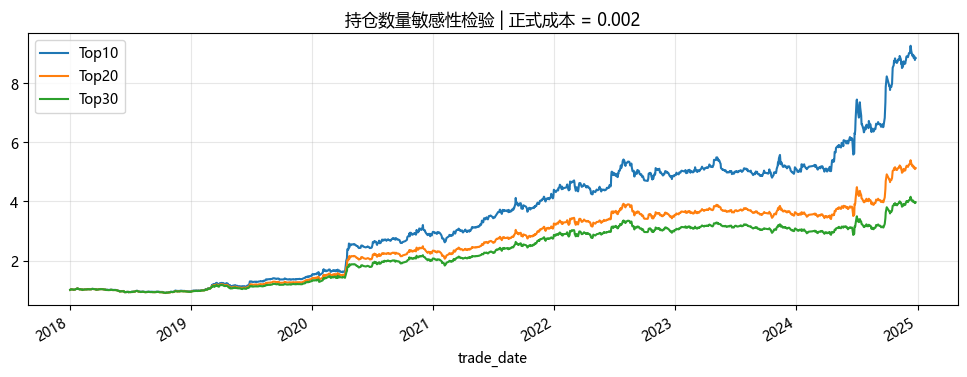

In [14]:
def run_main_style_topn(top_n: int, fee_rate: float = OFFICIAL_FEE_RATE) -> pd.DataFrame:
    if main_strategy_key == 'buffer_rank_weight_bw':
        return topn_buffer_rank_weight_backtest(
            score_panel=strategy_score_q20,
            fwd_ret_panel=fwd_ret_1d,
            buy_n=top_n,
            sell_n=top_n + 5,
            rebalance_freq=OFFICIAL_REBALANCE_FREQ,
            fee_rate=fee_rate,
        )
    return topn_buffer_equal_weight_backtest(
        score_panel=strategy_score_q20,
        fwd_ret_panel=fwd_ret_1d,
        buy_n=top_n,
        sell_n=top_n + 5,
        rebalance_freq=OFFICIAL_REBALANCE_FREQ,
        fee_rate=fee_rate,
    )

topn_results = {top_n: run_main_style_topn(top_n) for top_n in [10, 20, 30]}

topn_perf = pd.concat([
    summarize_performance(res['net_ret'], res['nav'], res['turnover']).rename(f'Top{top_n}')
    for top_n, res in topn_results.items()
], axis=1)
display(topn_perf)

topn_excess_summary = []
for top_n, res in topn_results.items():
    excess_ret = res['net_ret'] - benchmark_df['ret']
    excess_nav = (1 + excess_ret.fillna(0)).cumprod()
    topn_excess_summary.append(pd.Series({
        'excess_total_return': excess_nav.iloc[-1] - 1,
        'information_ratio': calc_ir(excess_ret),
    }, name=f'Top{top_n}'))

topn_excess_summary_df = pd.DataFrame(topn_excess_summary)
display(topn_excess_summary_df)

plt.figure(figsize=(12, 4))
for top_n, res in topn_results.items():
    res['nav'].plot(label=f'Top{top_n}')
plt.title('持仓数量敏感性检验 | 正式成本 = 0.002')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


,fee_0.0,fee_0.001,fee_0.002,fee_0.003
total_return,15.381276,11.048330,7.856612,5.506826
annual_return,0.495222,0.430575,0.368615,0.309235
annual_vol,0.209454,0.209379,0.209643,0.210245
sharpe,2.364349,2.056443,1.758304,1.470837
max_drawdown,-0.166768,-0.174646,-0.182464,-0.190223
calmar,2.969523,2.465417,2.020208,1.625647
win_rate,0.551887,0.539505,0.527123,0.516509
avg_turnover,0.181447,0.181447,0.181447,0.181447


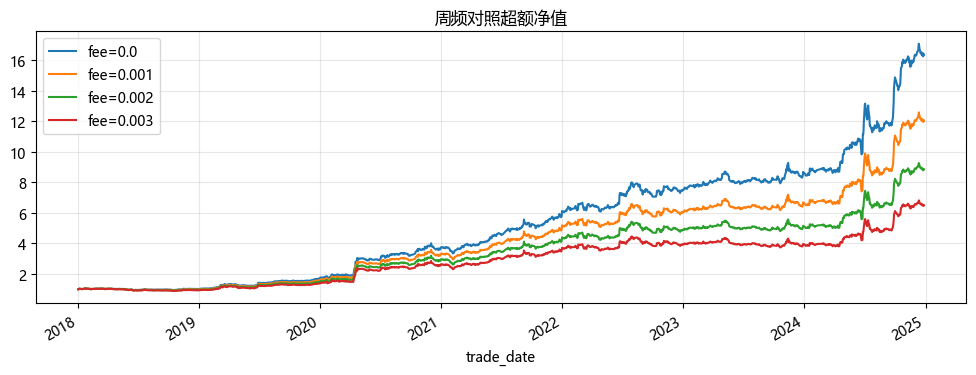

可比口径参数网格数量: 180


,topn,fee,filter,freq,weighting,annual_return,sharpe,max_drawdown,avg_turnover,information_ratio
30,10,0.002,q40,BW,equal_buffer,0.288084,1.514897,-0.183954,0.168254,1.230544
38,10,0.002,q60,BW,equal_buffer,0.284299,1.415170,-0.197937,0.166458,1.139927
22,10,0.002,q20,BW,equal_buffer,0.281998,1.486607,-0.181463,0.169340,1.196603
26,10,0.002,q30,BW,equal_buffer,0.275563,1.454324,-0.185302,0.169192,1.164187
34,10,0.002,q50,BW,equal_buffer,0.266231,1.381073,-0.177536,0.168533,1.086197
94,15,0.002,q50,BW,equal_buffer,0.263128,1.493129,-0.166201,0.159785,1.264933
90,15,0.002,q40,BW,equal_buffer,0.236255,1.391213,-0.166063,0.162759,1.105583
37,10,0.002,q60,W,equal_buffer,0.224926,1.153160,-0.256860,0.317128,0.818945
82,15,0.002,q20,BW,equal_buffer,0.216648,1.304633,-0.180704,0.162485,0.967505
142,20,0.002,q20,BW,equal_buffer,0.216557,1.420578,-0.160788,0.155845,1.131103


annual_return  sharpe  information_ratio
topn freq                                          
10   BW           0.2799  1.4535             1.1632
     D           -0.0714 -0.3990            -1.3957
     M            0.1463  0.8793             0.3855
     W            0.2111  1.1129             0.7384
15   BW           0.2289  1.3380             1.0416
     D           -0.0589 -0.3628            -1.5902
     M            0.1246  0.8268             0.2384
     W            0.1793  1.0570             0.6495
20   BW           0.2051  1.3062             1.0214
     D           -0.0703 -0.4683            -2.0352
     M            0.1163  0.8327             0.1658
     W            0.1523  0.9773             0.5061

In [15]:
fee_results = {}
for fee in FEE_SENSITIVITY_LIST:
    fee_results[fee] = run_main_style_topn(10, fee_rate=fee)

fee_perf = pd.concat([
    summarize_performance(res['net_ret'], res['nav'], res['turnover']).rename(f'fee_{fee}')
    for fee, res in fee_results.items()
], axis=1)
display(fee_perf)

plt.figure(figsize=(12, 4))
for fee, res in fee_results.items():
    res['nav'].plot(label=f'fee={fee}')
plt.title('周频对照超额净值')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

filter_score_map = {
    'q20': strategy_score_q20,
    'q30': strategy_score_q30,
    'q40': strategy_score_q40,
    'q50': strategy_score_q50,
    'q60': strategy_score_q60,
}
param_grid_rows = []
for top_n in [10, 15, 20]:
    for fee in [0.001, 0.002, 0.003]:
        for filter_name, score_panel_for_grid in filter_score_map.items():
            for freq in ['D', 'W', 'BW', 'M']:
                grid_result = topn_buffer_equal_weight_backtest(
                    score_panel=score_panel_for_grid,
                    fwd_ret_panel=fwd_ret_1d,
                    buy_n=top_n,
                    sell_n=top_n + 5,
                    rebalance_freq=freq,
                    fee_rate=fee,
                )
                grid_perf = summarize_performance(
                    grid_result['net_ret'],
                    grid_result['nav'],
                    grid_result['turnover'],
                )
                excess_ret = grid_result['net_ret'] - benchmark_df['ret']
                param_grid_rows.append({
                    'topn': top_n,
                    'fee': fee,
                    'filter': filter_name,
                    'freq': freq,
                    'weighting': 'equal_buffer',
                    'annual_return': grid_perf['annual_return'],
                    'sharpe': grid_perf['sharpe'],
                    'max_drawdown': grid_perf['max_drawdown'],
                    'avg_turnover': grid_perf['avg_turnover'],
                    'information_ratio': calc_ir(excess_ret),
                })

param_grid_comparable_df = pd.DataFrame(param_grid_rows)
print('可比口径参数网格数量:', len(param_grid_comparable_df))
display(param_grid_comparable_df[param_grid_comparable_df['fee'].eq(OFFICIAL_FEE_RATE)].sort_values('annual_return', ascending=False).head(10))
display(param_grid_comparable_df.groupby(['topn', 'freq'])[['annual_return', 'sharpe', 'information_ratio']].mean().round(4))


,total_return,annual_return,annual_vol,sharpe,max_drawdown,calmar,win_rate,avg_turnover
2018-2020,1.971931,0.439168,0.217271,2.021290,-0.143934,3.051180,0.532877,0.160897
2021-2022,0.648533,0.285939,0.186052,1.536879,-0.133842,2.136391,0.529897,0.200419
2023-2024,0.807720,0.350320,0.220372,1.589672,-0.148801,2.354291,0.515593,0.193505


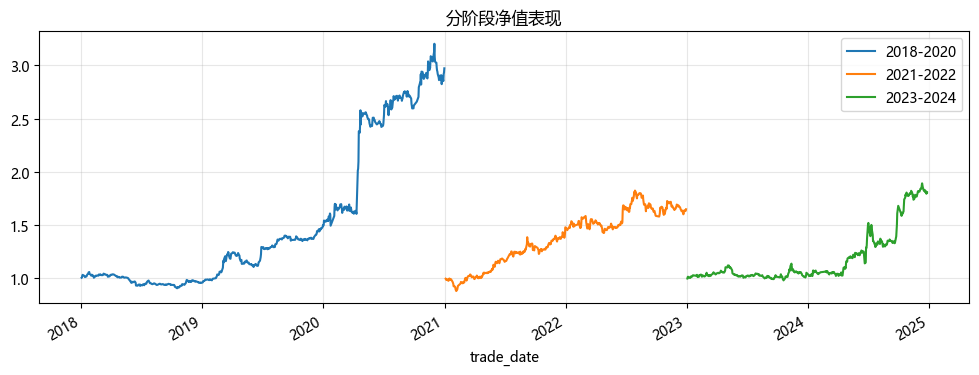

,基础等权 Top10,等权 BW 缓冲对照,缓冲排名加权 BW 候选,无缓冲 Top10 排名加权对照,最终主策略
total_return,5.613713,4.622178,7.856612,8.299883,7.856612
annual_return,0.312308,0.281998,0.368615,0.378265,0.368615
annual_vol,0.192236,0.189692,0.209643,0.212552,0.209643
sharpe,1.624608,1.486607,1.758304,1.779634,1.758304
max_drawdown,-0.179694,-0.181463,-0.182464,-0.181878,-0.182464
calmar,1.737995,1.554025,2.020208,2.079772,2.020208
win_rate,0.533608,0.526533,0.527123,0.528892,0.527123
avg_turnover,0.180660,0.169340,0.181447,0.184681,0.181447
excess_total_return,2.339450,1.843002,3.482913,3.707050,3.482913
information_ratio,1.325495,1.196603,1.435558,1.448632,1.435558


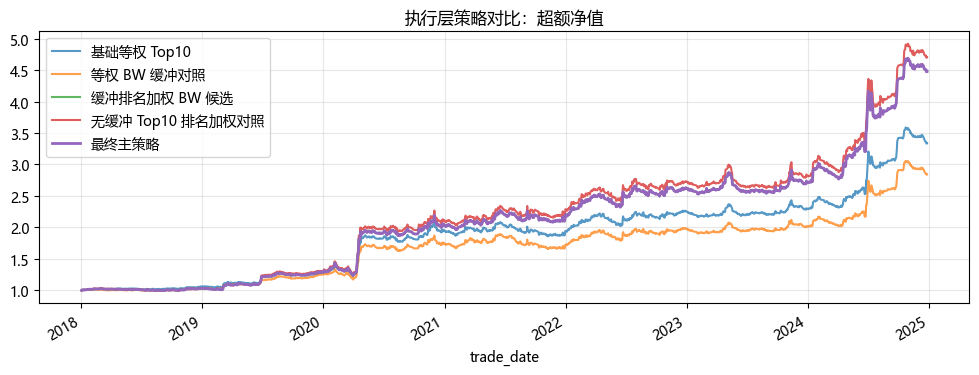

,等权 BW 缓冲,缓冲排名加权 BW
total_return,1.208044,1.980086
annual_return,0.221497,0.317603
annual_vol,0.183288,0.203766
sharpe,1.208465,1.558662
max_drawdown,-0.130262,-0.148801
calmar,1.700397,2.134420
win_rate,0.531056,0.522774
avg_turnover,0.190442,0.196976
excess_total_return,0.631158,1.202799
information_ratio,1.018931,1.355507


,total_return,annual_return,annual_vol,sharpe,max_drawdown,calmar,win_rate,avg_turnover,excess_total_return,information_ratio,selected_strategy,train_years
2021,0.479546,0.481933,0.180302,2.672928,-0.117937,4.086373,0.563786,0.201011,0.081758,0.637689,缓冲排名加权 BW,2018-2020
2022,0.114215,0.115212,0.191597,0.601324,-0.133842,0.860804,0.495868,0.199825,0.192399,1.351743,缓冲排名加权 BW,2019-2021
2023,0.049661,0.050081,0.130956,0.382429,-0.124774,0.401376,0.495868,0.190562,0.038007,0.401043,缓冲排名加权 BW,2020-2022
2024,0.722194,0.741892,0.282810,2.623288,-0.148801,4.985814,0.535565,0.196485,0.645216,2.444753,缓冲排名加权 BW,2021-2023


,rolling_selection_validation
total_return,1.980086
annual_return,0.317603
annual_vol,0.203766
sharpe,1.558662
max_drawdown,-0.148801
calmar,2.134420
win_rate,0.522774
avg_turnover,0.196976
excess_total_return,1.202799
information_ratio,1.355507


,最终主策略,2%阈值再平衡附录
annual_return,0.368615,0.280487
sharpe,1.758304,1.483602
max_drawdown,-0.182464,-0.181526
avg_turnover,0.181447,0.168598
excess_total_return,3.482913,1.819160
information_ratio,1.435558,1.192612


,rule,score_gap_threshold,freq,annual_return,sharpe,max_drawdown,avg_turnover,total_return
0,fixed_BW,NaN,BW,0.281998,1.486607,-0.181463,0.169340,4.622178
1,gap_0.05,0.05,BW,0.297626,1.556935,-0.179901,0.176061,5.116193
2,gap_0.10,0.10,BW,0.295267,1.546806,-0.179901,0.173231,5.039322
3,gap_0.20,0.20,BW,0.296298,1.552668,-0.179901,0.170873,5.072840
4,gap_0.30,0.30,BW,0.296338,1.552773,-0.179901,0.169811,5.074123
5,gap_0.50,0.50,BW,0.298080,1.562861,-0.179901,0.168986,5.131099


In [16]:
date_index = main_result.index
stage_1_end = pd.Timestamp('2020-12-31')
stage_2_end = pd.Timestamp('2022-12-31')

stage_masks = {
    '2018-2020': date_index <= stage_1_end,
    '2021-2022': (date_index > stage_1_end) & (date_index <= stage_2_end),
    '2023-2024': date_index > stage_2_end,
}

stage_perf_list = []
for stage_name, mask in stage_masks.items():
    sub_ret = main_result.loc[mask, 'net_ret']
    sub_nav = (1 + sub_ret.fillna(0)).cumprod()
    sub_turnover = main_result.loc[mask, 'turnover']
    s = summarize_performance(sub_ret, sub_nav, sub_turnover)
    s.name = stage_name
    stage_perf_list.append(s)

stage_perf_df = pd.DataFrame(stage_perf_list)
display(stage_perf_df)

plt.figure(figsize=(12, 4))
for stage_name, mask in stage_masks.items():
    sub_ret = main_result.loc[mask, 'net_ret']
    sub_nav = (1 + sub_ret.fillna(0)).cumprod()
    sub_nav.plot(label=stage_name)
plt.title('分阶段净值表现')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

execution_results = {
    '基础等权 Top10': baseline_equal_result,
    '等权 BW 缓冲对照': equal_bw_result,
    '缓冲排名加权 BW 候选': buffer_rank_weight_result,
    '无缓冲 Top10 排名加权对照': unbuffered_rank_weight_result,
}
if main_strategy_key == 'buffer_rank_weight_bw':
    execution_results['最终主策略'] = buffer_rank_weight_result
else:
    execution_results['最终主策略'] = equal_bw_result

execution_compare = {}
execution_excess_navs = {}
for name, result in execution_results.items():
    perf = summarize_performance(result['net_ret'], result['nav'], result['turnover'])
    excess_ret = result['net_ret'] - benchmark_df['ret']
    excess_nav = (1 + excess_ret.fillna(0)).cumprod()
    execution_excess_navs[name] = excess_nav
    perf['excess_total_return'] = excess_nav.iloc[-1] - 1
    perf['information_ratio'] = calc_ir(excess_ret)
    execution_compare[name] = perf

execution_compare_df = pd.DataFrame(execution_compare)
display(execution_compare_df)

plt.figure(figsize=(12, 4))
for name, nav in execution_excess_navs.items():
    if name != '最终主策略':
        nav.plot(label=name, alpha=0.75)
execution_excess_navs['最终主策略'].plot(label='最终主策略', linewidth=2.0)
plt.title('执行层策略对比：超额净值')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

rolling_fixed_summaries = pd.DataFrame({
    '等权 BW 缓冲': equal_bw_rolling_summary,
    '缓冲排名加权 BW': buffer_rank_rolling_summary,
})
display(rolling_fixed_summaries)

rolling_candidates = {
    '等权 BW 缓冲': equal_bw_result,
    '缓冲排名加权 BW': buffer_rank_weight_result,
}
rolling_validation_table, rolling_validation_summary = run_rolling_train_validate(
    candidate_results=rolling_candidates,
    benchmark_ret=benchmark_df['ret'],
    train_years=3,
)
display(rolling_validation_table)
display(rolling_validation_summary.to_frame('rolling_selection_validation'))

threshold_test_result = topn_buffer_threshold_backtest(
    score_panel=strategy_score_q20,
    fwd_ret_panel=fwd_ret_1d,
    buy_n=10,
    sell_n=15,
    rebalance_freq=OFFICIAL_REBALANCE_FREQ,
    fee_rate=OFFICIAL_FEE_RATE,
    trade_threshold=0.02,
)

threshold_compare_df = pd.DataFrame({
    '最终主策略': make_strategy_snapshot(main_result, benchmark_df['ret']),
    '2%阈值再平衡附录': make_strategy_snapshot(threshold_test_result, benchmark_df['ret']),
})
display(threshold_compare_df.loc[['annual_return', 'sharpe', 'max_drawdown', 'avg_turnover', 'excess_total_return', 'information_ratio']])

try:
    dynamic_gap_appendix_df = pd.read_csv('../report/dynamic_threshold_results.csv')
    display(dynamic_gap_appendix_df)
except FileNotFoundError:
    dynamic_gap_appendix_df = pd.DataFrame()
    print('未找到 dynamic_threshold_results.csv，跳过动态 gap 附录表。')


### 执行层归因

前面的绩效表已经能看出主策略整体更好，但增量来自哪里还要拆开看。这里比较几个已经出现过的版本：

- 基础等权对照策略：只反映 3 因子等权排序本身；
- 主策略：在此基础上加入 `amount q20` 可交易性过滤和 `Top10 / Top15` 缓冲区；
- 无缓冲 Top10 排名加权对照：检验取消缓冲区、同时强化前排持仓权重后的结果。

如果主策略比基础等权更好，而无缓冲排名加权并没有带来更清楚的改进，就说明增量主要来自可交易性约束和缓冲换手，而不是单纯加大头部权重。


In [17]:
strategy_attribution_df = execution_compare_df.loc[
    ['annual_return', 'sharpe', 'max_drawdown', 'avg_turnover', 'excess_total_return', 'information_ratio'],
    ['基础等权 Top10', '等权 BW 缓冲对照', '缓冲排名加权 BW 候选', '无缓冲 Top10 排名加权对照', '最终主策略']
].copy()

strategy_attribution_df['缓冲排名加权 - 等权 BW'] = (
    strategy_attribution_df['缓冲排名加权 BW 候选'] - strategy_attribution_df['等权 BW 缓冲对照']
)
strategy_attribution_df['无缓冲排名加权 - 等权 BW'] = (
    strategy_attribution_df['无缓冲 Top10 排名加权对照'] - strategy_attribution_df['等权 BW 缓冲对照']
)
display(strategy_attribution_df)


,基础等权 Top10,等权 BW 缓冲对照,缓冲排名加权 BW 候选,无缓冲 Top10 排名加权对照,最终主策略,缓冲排名加权 - 等权 BW,无缓冲排名加权 - 等权 BW
annual_return,0.312308,0.281998,0.368615,0.378265,0.368615,0.086618,0.096268
sharpe,1.624608,1.486607,1.758304,1.779634,1.758304,0.271697,0.293028
max_drawdown,-0.179694,-0.181463,-0.182464,-0.181878,-0.182464,-0.001001,-0.000416
avg_turnover,0.180660,0.169340,0.181447,0.184681,0.181447,0.012107,0.015340
excess_total_return,2.339450,1.843002,3.482913,3.707050,3.482913,1.639911,1.864047
information_ratio,1.325495,1.196603,1.435558,1.448632,1.435558,0.238954,0.252029


### 滚动验证可视化

下面把固定 3 年训练 + 1 年验证的结果画出来，并列出每个验证年的指标。



,train_years,selected_strategy,annual_return,sharpe,max_drawdown,avg_turnover,excess_total_return,information_ratio
validation_year,,,,,,,,
2021,2018-2020,缓冲排名加权 BW,0.481933,2.672928,-0.117937,0.201011,0.081758,0.637689
2022,2019-2021,缓冲排名加权 BW,0.115212,0.601324,-0.133842,0.199825,0.192399,1.351743
2023,2020-2022,缓冲排名加权 BW,0.050081,0.382429,-0.124774,0.190562,0.038007,0.401043
2024,2021-2023,缓冲排名加权 BW,0.741892,2.623288,-0.148801,0.196485,0.645216,2.444753


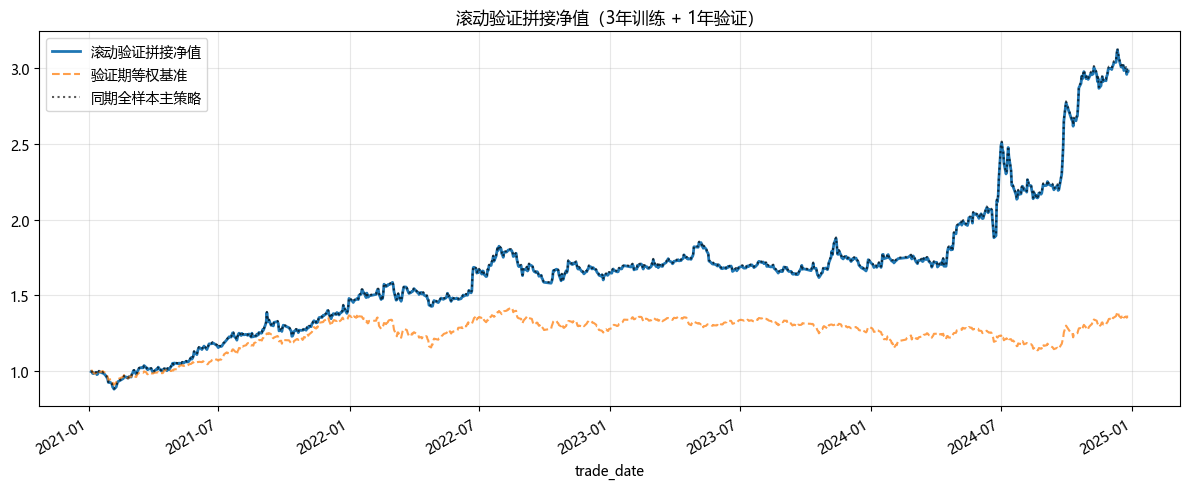

In [18]:
# ── 滚动验证拼接净值图和逐年指标表 ──
rolling_yearly_df = rolling_validation_table.copy()
rolling_yearly_df.index.name = 'validation_year'
display_cols = ['train_years', 'selected_strategy', 'annual_return', 'sharpe',
                'max_drawdown', 'avg_turnover', 'excess_total_return', 'information_ratio']
display(rolling_yearly_df[display_cols])

rolling_nav_by_year = {}
stitched_ret_parts = []

for validation_year, row in rolling_validation_table.iterrows():
    selected_strategy = row['selected_strategy']
    valid_result = rolling_candidates[selected_strategy].loc[
        rolling_candidates[selected_strategy].index.year == int(validation_year)
    ]
    if valid_result.empty:
        continue
    valid_ret = valid_result['net_ret'].fillna(0)
    valid_nav = (1 + valid_ret).cumprod()
    rolling_nav_by_year[int(validation_year)] = valid_nav / valid_nav.iloc[0]
    stitched_ret_parts.append(valid_ret)

stitched_ret = pd.concat(stitched_ret_parts).sort_index()
stitched_nav = (1 + stitched_ret.fillna(0)).cumprod()
stitched_benchmark_nav = (1 + benchmark_df['ret'].reindex(stitched_ret.index).fillna(0)).cumprod()
main_nav_compare = main_result['nav'].reindex(stitched_ret.index).ffill()
main_nav_compare = main_nav_compare / main_nav_compare.iloc[0]

fig, ax = plt.subplots(figsize=(12, 5))
stitched_nav.plot(ax=ax, label='滚动验证拼接净值', linewidth=2.0)
stitched_benchmark_nav.plot(ax=ax, label='验证期等权基准', linestyle='--', alpha=0.75)
main_nav_compare.plot(ax=ax, label='同期全样本主策略', color='black', linestyle=':', alpha=0.65)
ax.set_title('滚动验证拼接净值（3年训练 + 1年验证）')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 稳健性小结

- TopN 测试只用于观察持仓集中度敏感性，不用于继续搜索最优参数。
- 手续费仍会压缩收益。正式结果采用 `fee_rate = 0.002`，低费率结果只作为成本敏感性参照。
- 日频、周频、双周和月频对比用于回答调仓频率问题；当前样本下 BW 双周更好地平衡了信号反应和交易成本。
- 执行层对比分开观察等权 BW、缓冲排名加权和无缓冲 Top10 排名加权；只有保留缓冲区的排名加权版本进入正式主策略。
- 滚动 3 年训练 + 1 年验证用于提醒：不能过度解读全样本结果。


## 风险提示与结论

### 风险提示

1. 手续费上升会压缩策略收益；正式成本口径为 `fee_rate = 0.002`。
2. 排名加权会提高头部持仓集中度；如果前排标的失效，短期回撤可能放大。
3. 日频和周频调仓换手较高；BW 双周调仓降低换手，但真实交易冲击仍需要考虑。
4. `amount q20` 过滤不能完全消除小规模转债的流动性冲击。
5. 强赎、退市、信用事件、停牌和异常成交没有完全建模。
6. 正股下跌会传导到转债价格；`alpha_pct_chg_5` 不能替代风险控制。
7. 因子筛选、参数网格、权重规则比较和全样本回测都存在样本内优化风险。
8. 执行假设为收盘后信号、收盘调仓、次日起算收益，真实成交价格可能不同。

### 结论

`dblow`、`bond_prem` 和 `alpha_pct_chg_5` 构成一组可解释的三因子评分。证据来自分组检验、IC/RankIC、多空 20% 对冲检验和组合回测。

确定 BW 双周调仓后，保留缓冲区的排名加权版本通过手续费、分阶段表现和滚动验证等检验，因此作为最终主策略。

最终缓冲排名加权 BW 策略年化收益约 `36.86%`，夏普约 `1.7583`，最大回撤约 `-18.25%`，超额累计收益约 `348.29%`，IR 约 `1.4356`。这些结果有参考价值，但还不能直接等同于实盘策略。
